# **EDA**

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
ruta = "/content/drive/Shared drives/ETL_second_delivery/"

In [37]:
#instalar sweetviz para facilitar el EDA
!pip install -q sweetviz

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv
from sweetviz import FeatureConfig
import warnings
warnings.filterwarnings("ignore")

#cargar los datasets transformados
df_fact   = pd.read_csv(ruta + "tf_fact.csv")
df_covid  = pd.read_csv(ruta + "tf_covid.csv")
df_uhc    = pd.read_csv(ruta + "tf_uhc.csv")
df_merged = pd.read_csv(ruta + "tf_merged.csv")

print()
for nombre, df in [("tf_fact", df_fact), ("tf_covid", df_covid),
                   ("tf_uhc", df_uhc), ("tf_merged", df_merged)]:
    print(f"{nombre:<12}: {df.shape[0]:>8,} filas  x  {df.shape[1]:>3} columnas")


tf_fact     :   66,320 filas  x   12 columnas
tf_covid    :    1,143 filas  x    5 columnas
tf_uhc      :       24 filas  x    2 columnas
tf_merged   :        1 filas  x    9 columnas


---
##Calidad de los datos



In [39]:
# Tabla resumen de calidad para los 4 datasets
resumen = []
for nombre, df in [("tf_fact", df_fact), ("tf_covid", df_covid),
                   ("tf_uhc", df_uhc), ("tf_merged", df_merged)]:
    nulos_total = df.isnull().sum().sum()
    cols_con_nulos = (df.isnull().sum() > 0).sum()
    resumen.append({
        "dataset"         : nombre,
        "filas"           : len(df),
        "columnas"        : df.shape[1],
        "nulos_total"     : nulos_total,
        "cols_con_nulos"  : cols_con_nulos,
        "duplicados"      : df.duplicated().sum(),
        "tipos"           : df.dtypes.value_counts().to_dict()
    })

df_quality = pd.DataFrame(resumen).drop(columns=["tipos"])
print("Resumen de calidad")
print(df_quality.to_string(index=False))

print("\n Nulos por columna ")
for nombre, df in [("tf_fact", df_fact), ("tf_covid", df_covid),
                   ("tf_uhc", df_uhc), ("tf_merged", df_merged)]:
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]
    if len(nulos) > 0:
        print(f"\n[{nombre}]")
        for col, n in nulos.items():
            print(f"  {col}: {n} nulos ({100*n/len(df):.1f}%)")
    else:
        print(f"\n[{nombre}] — sin nulos")

Resumen de calidad
  dataset  filas  columnas  nulos_total  cols_con_nulos  duplicados
  tf_fact  66320        12            0               0           0
 tf_covid   1143         5            0               0           0
   tf_uhc     24         2            0               0           0
tf_merged      1         9            0               0           0

 Nulos por columna 

[tf_fact] — sin nulos

[tf_covid] — sin nulos

[tf_uhc] — sin nulos

[tf_merged] — sin nulos


##Reportes automaticos con Sweetviz

Sweetviz genera un reporte HTML interactivo por dataset. Se guardan en drive para referencia.

                                             |          | [  0%]   00:00 -> (? left)

Report /content/drive/Shared drives/ETL_final_delivery/sweetviz_fact.html was generated.
Reporte tf_fact guardado en Drive



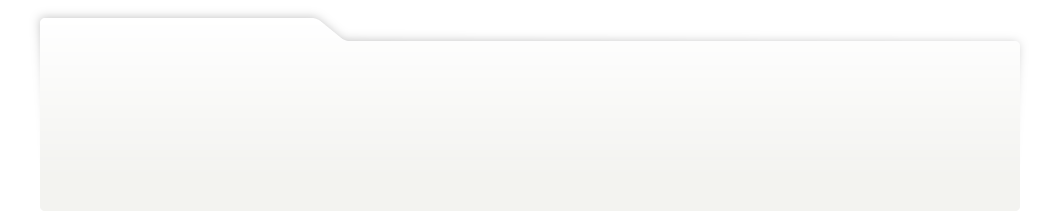
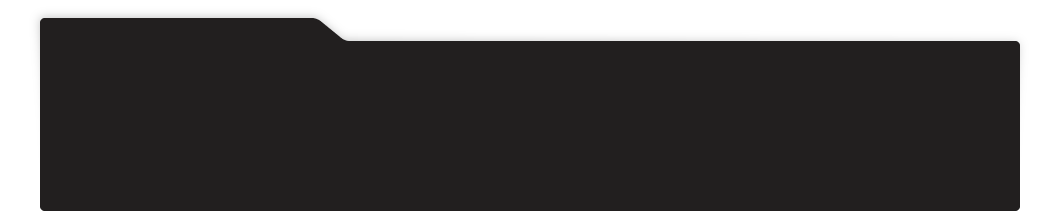
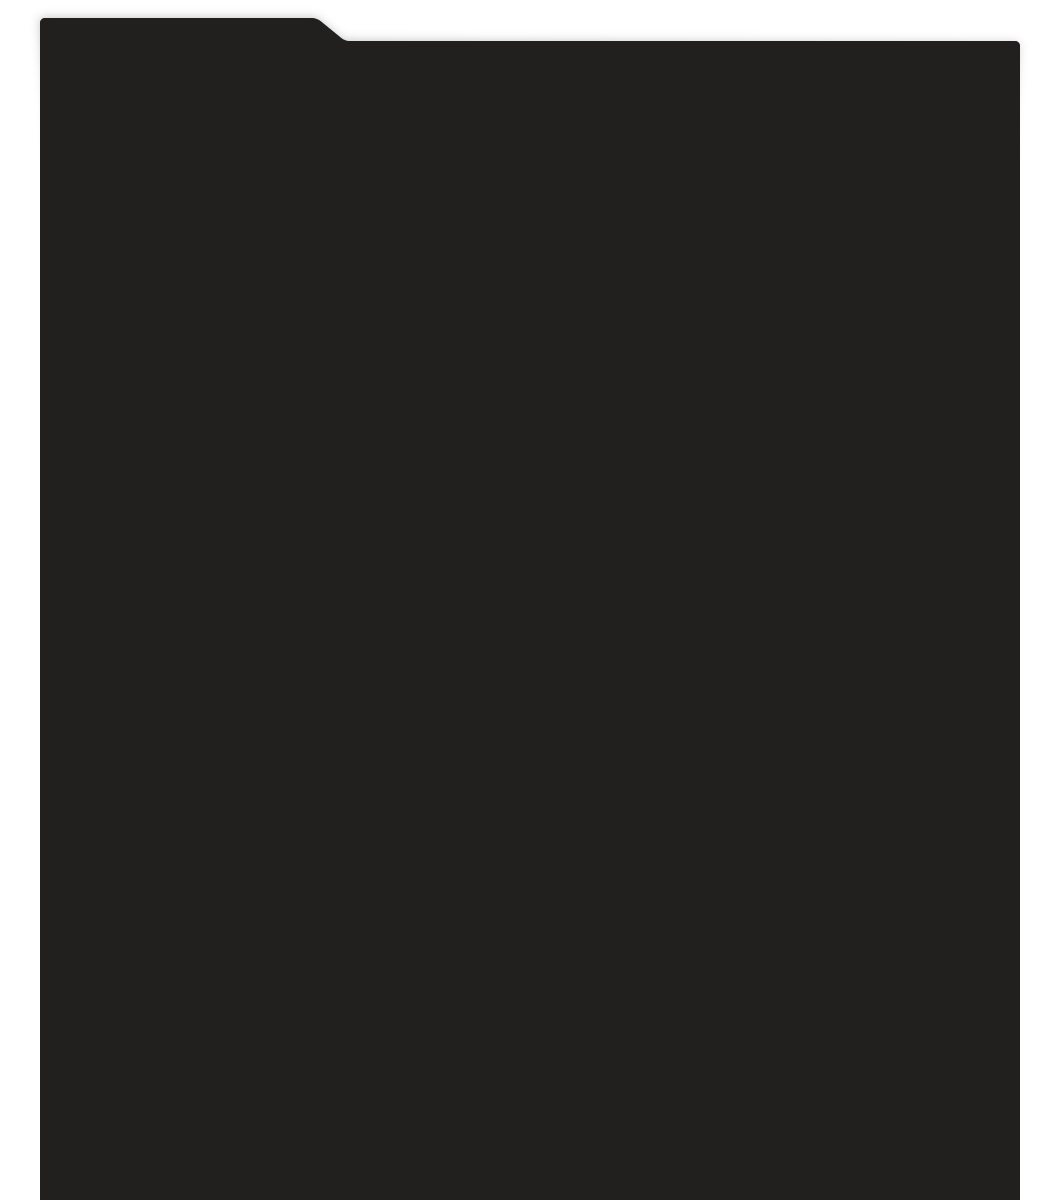
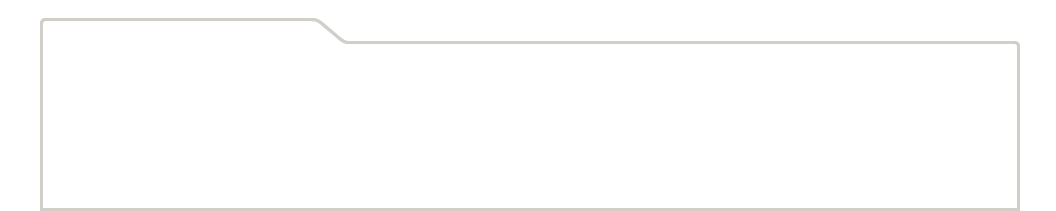
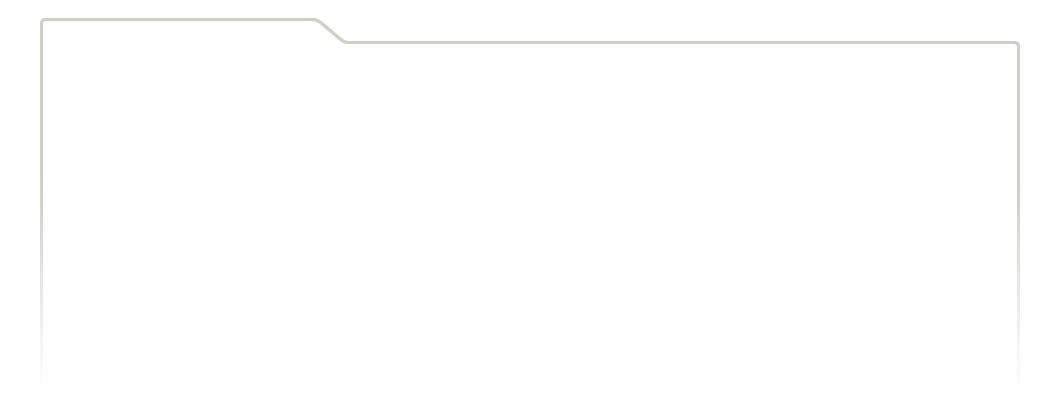
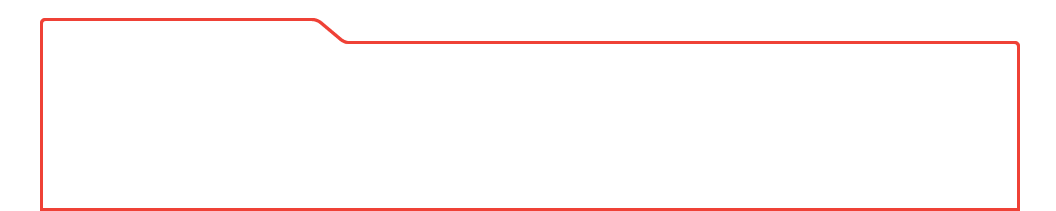
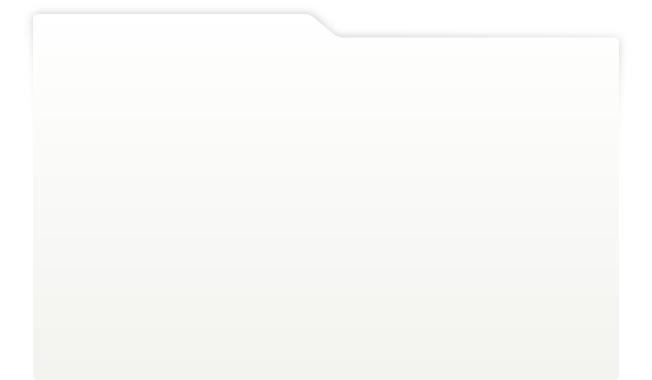
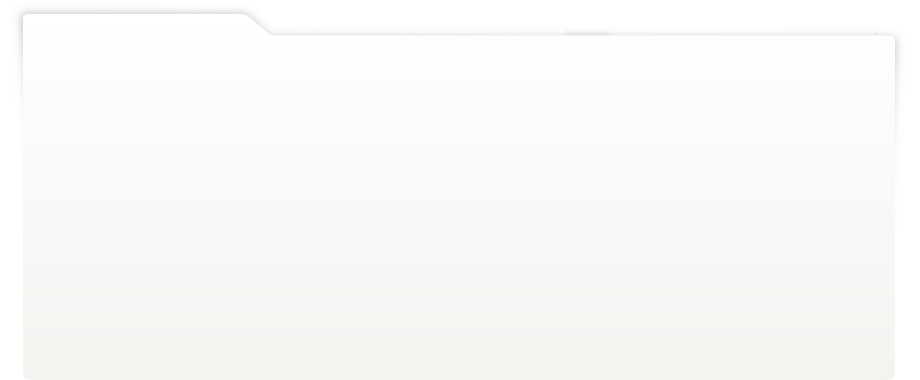
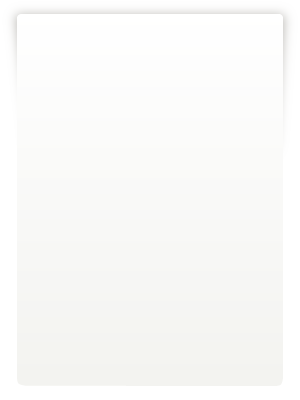
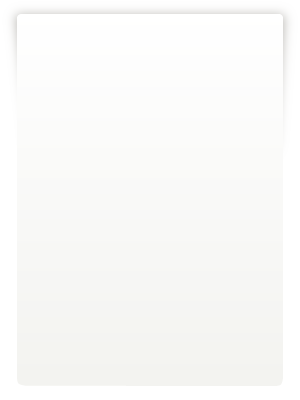
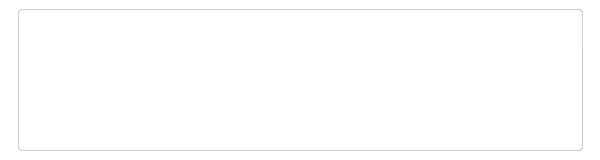
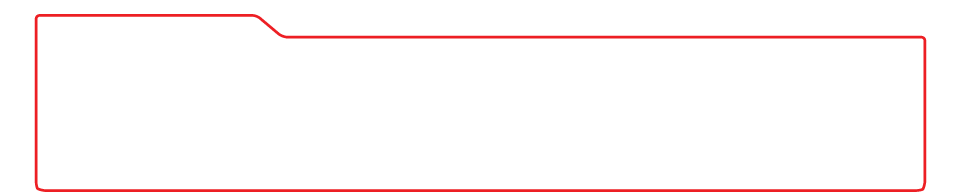
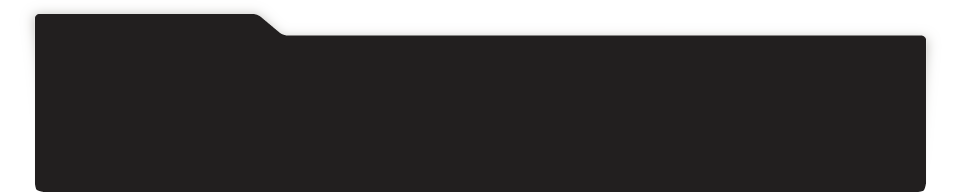
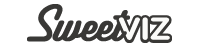
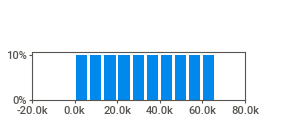
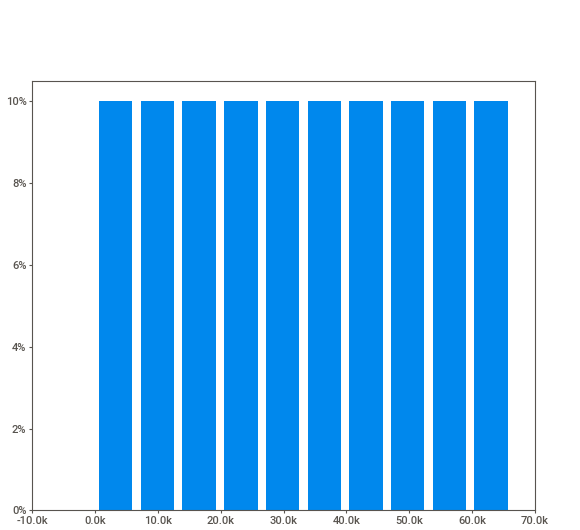
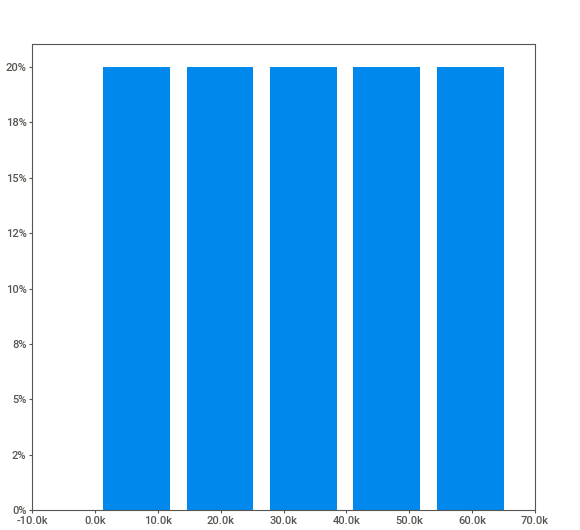
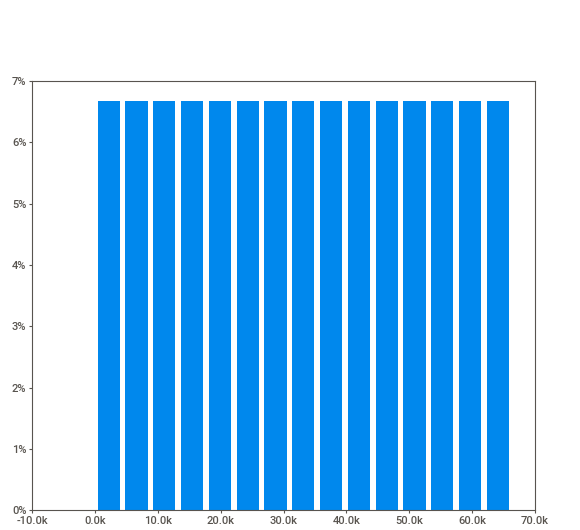
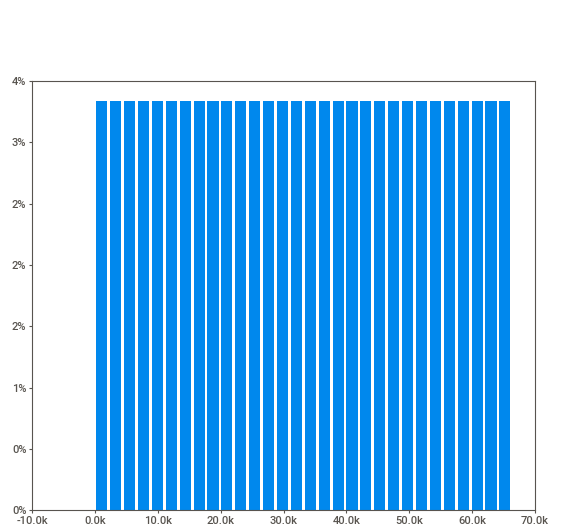
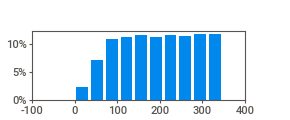
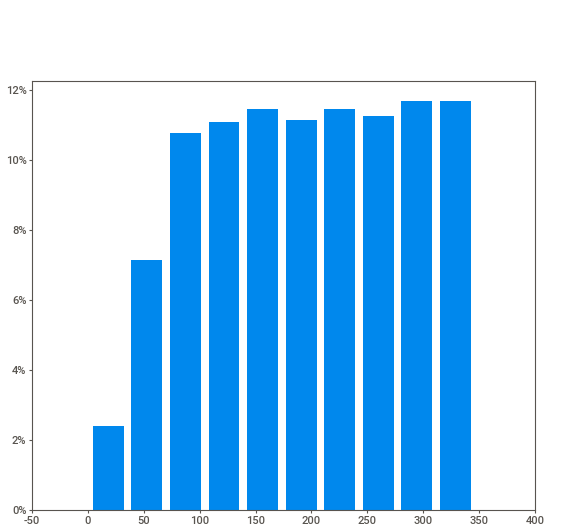
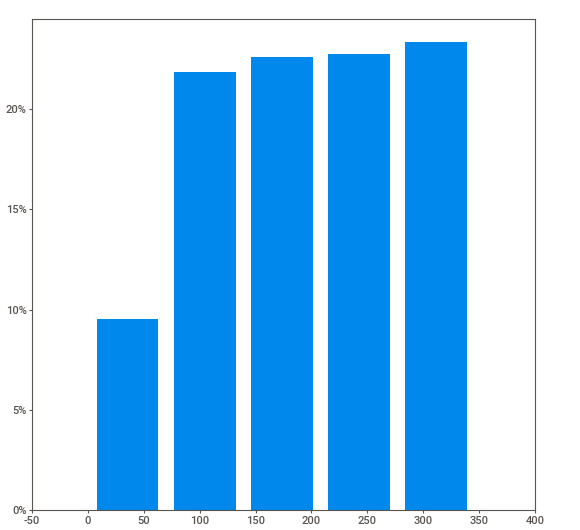
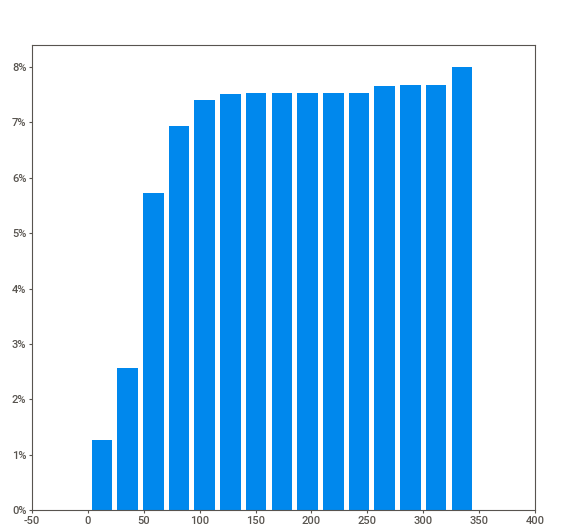
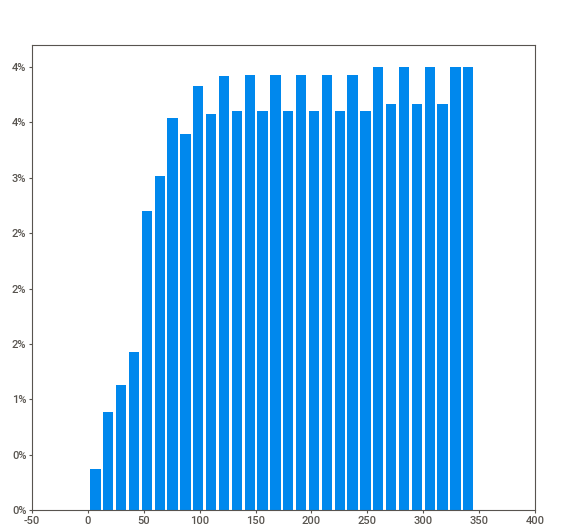
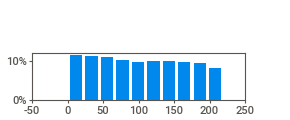
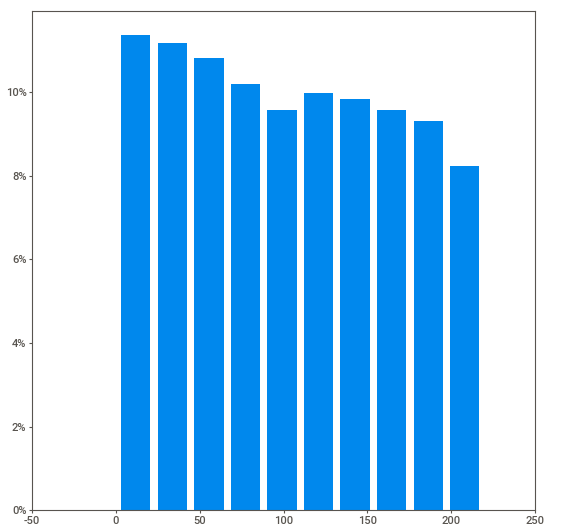
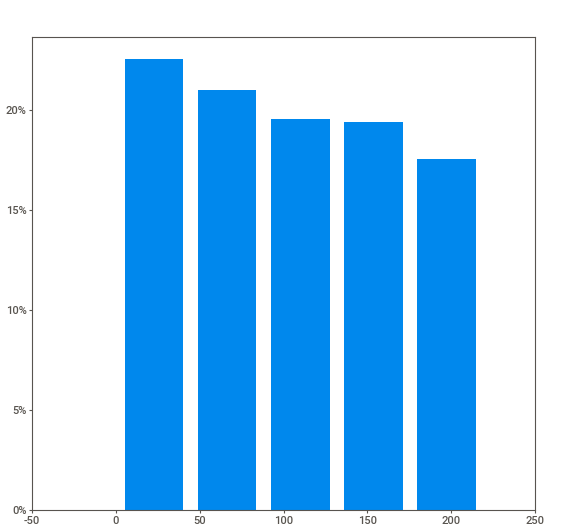
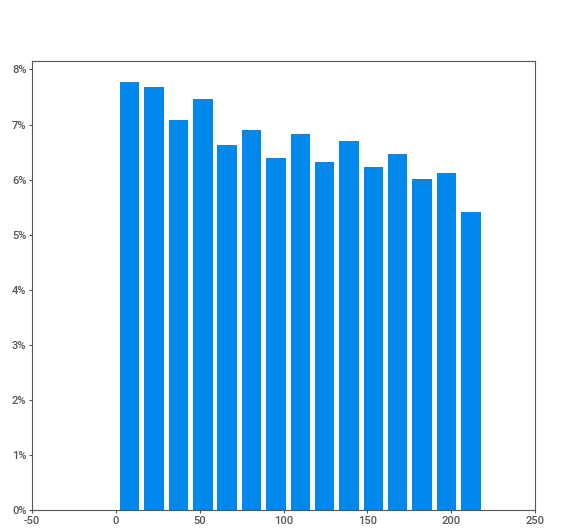
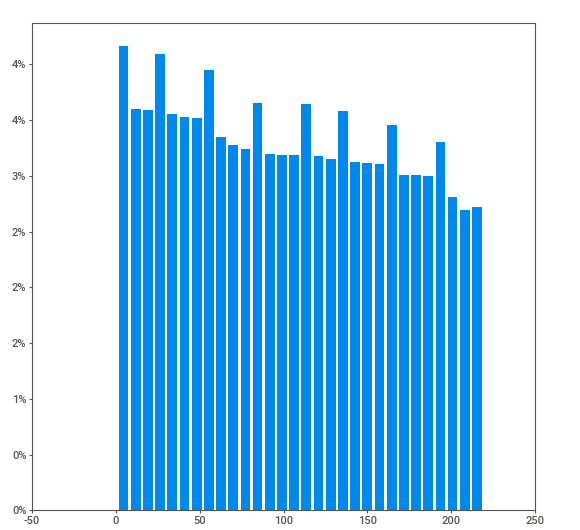
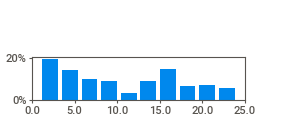
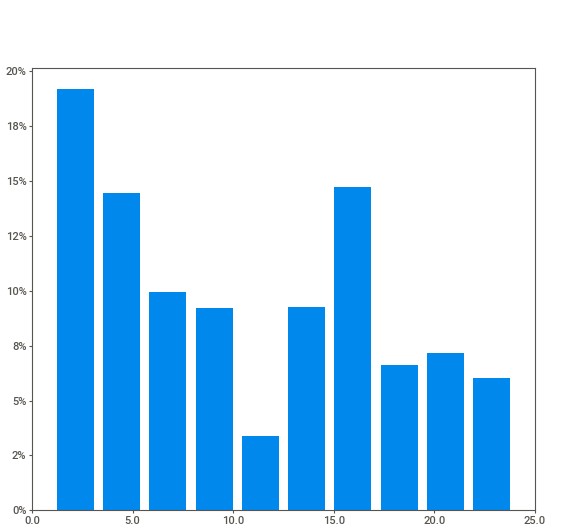
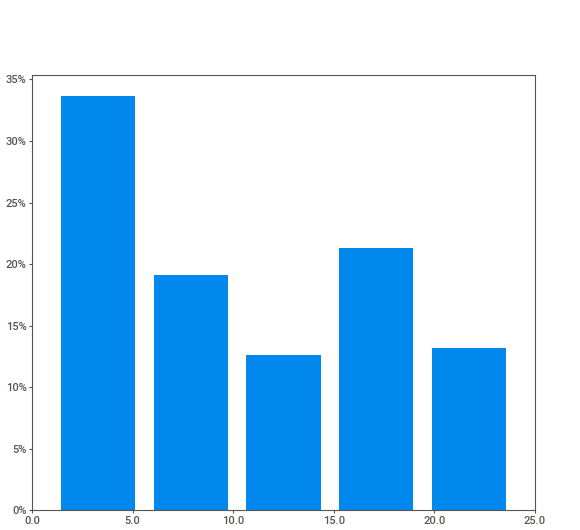
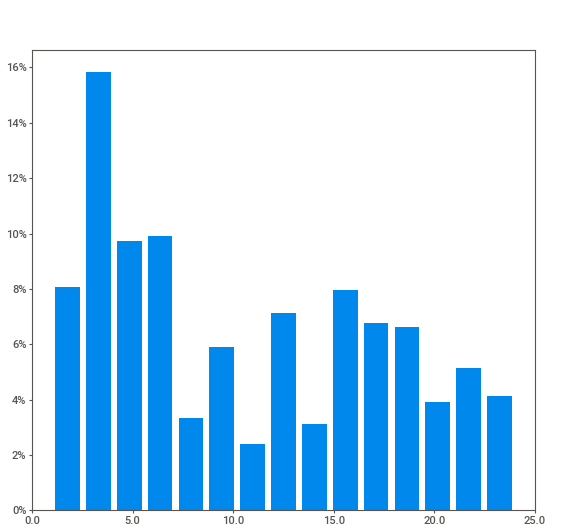
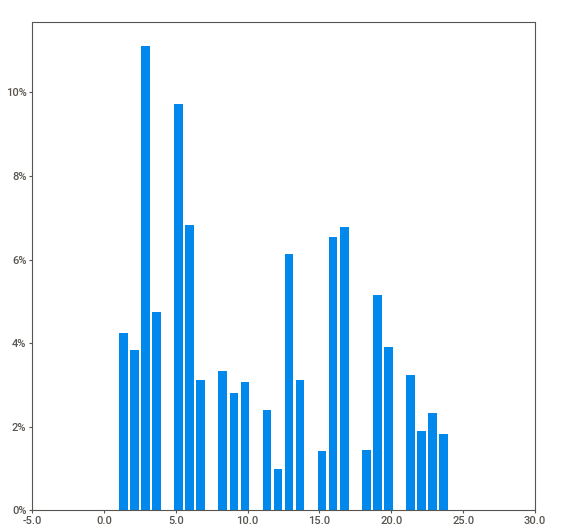
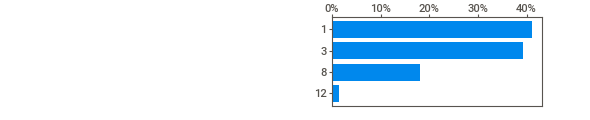
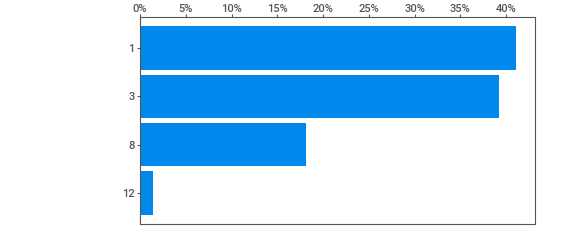
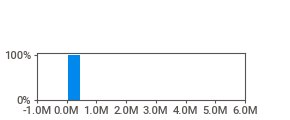
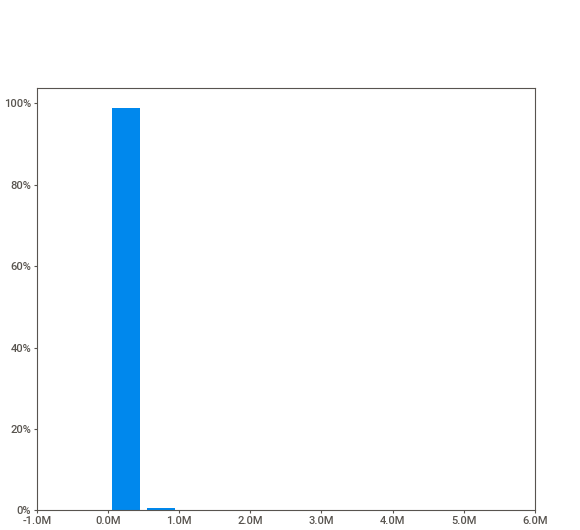
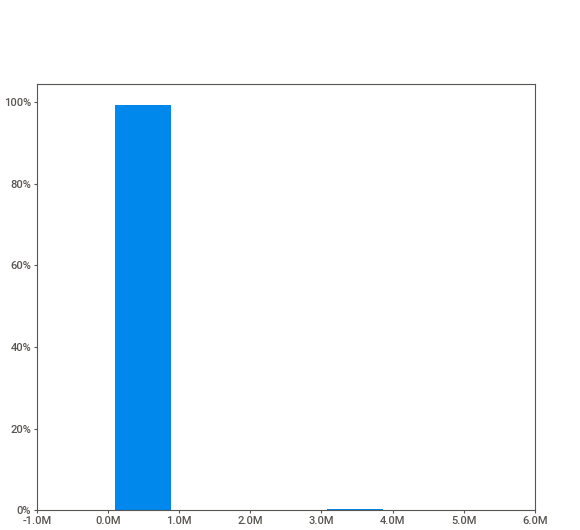
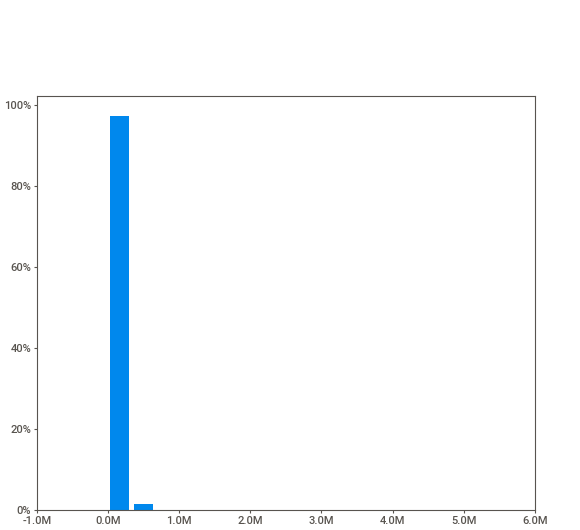
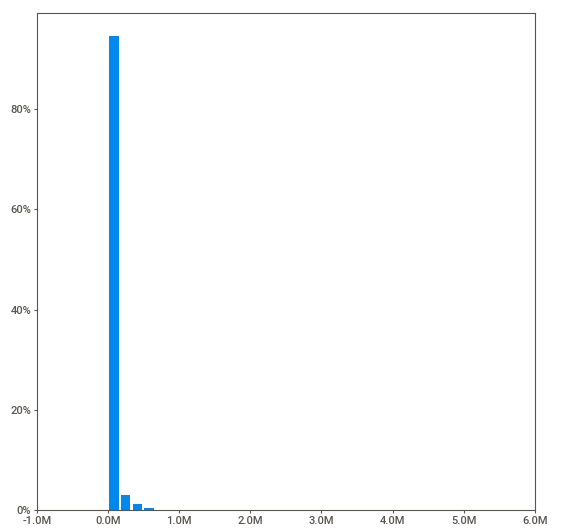
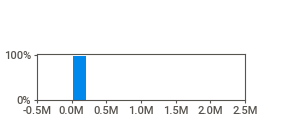
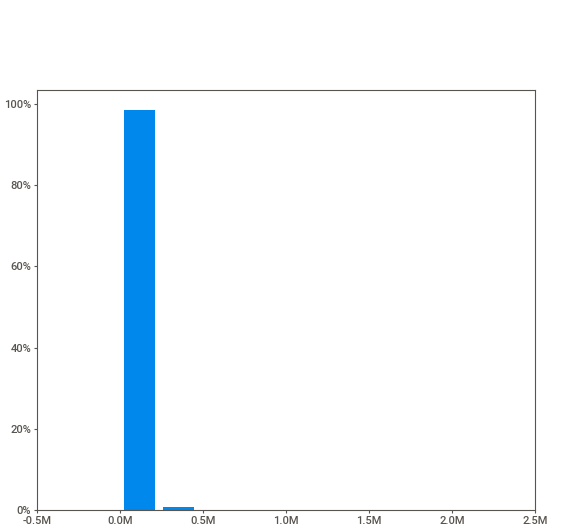
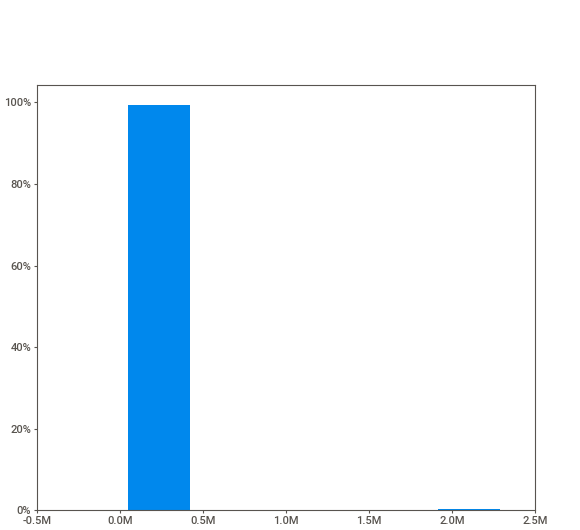
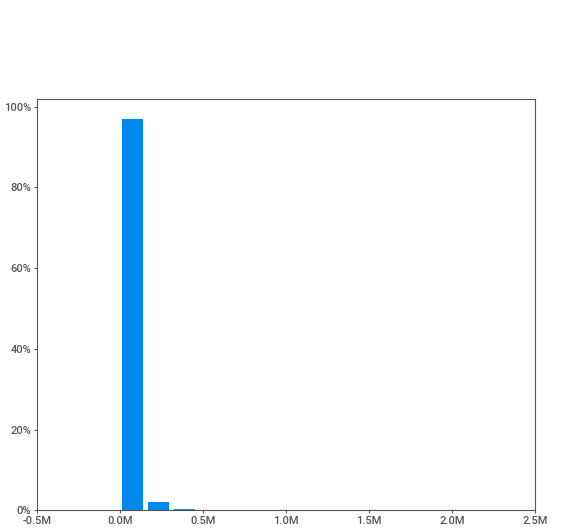
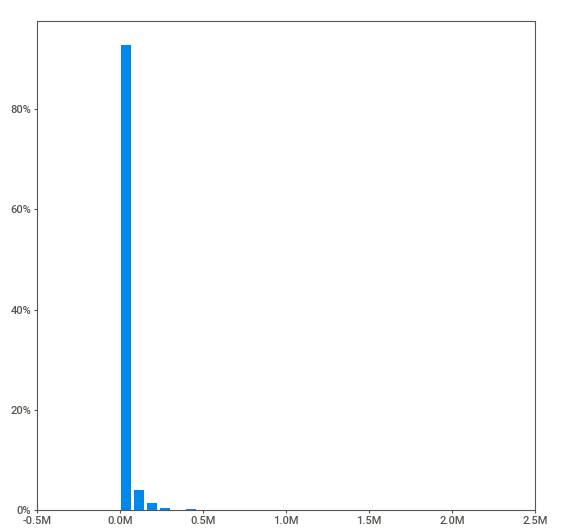
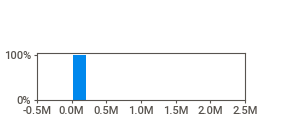
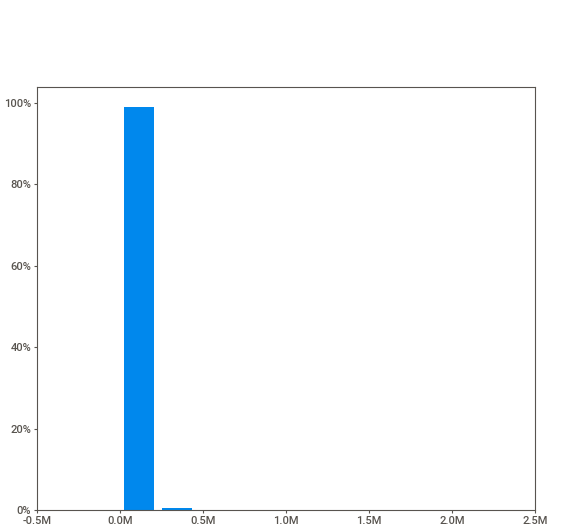
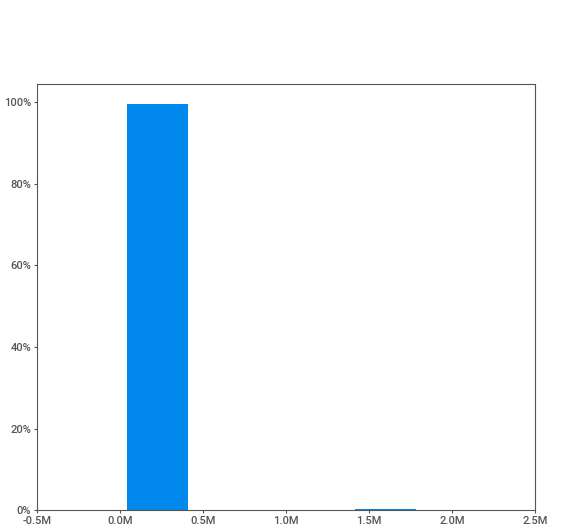
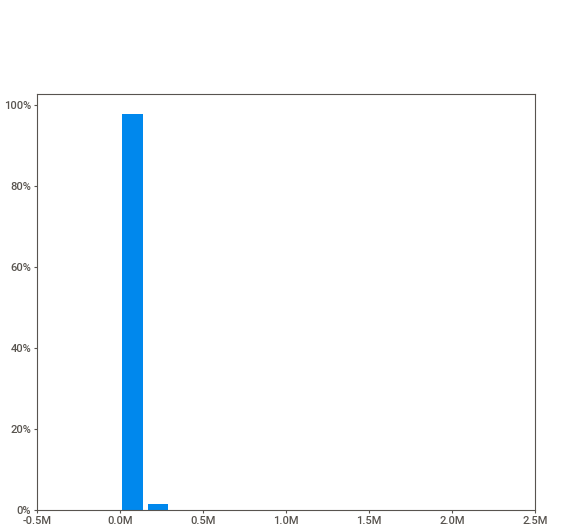
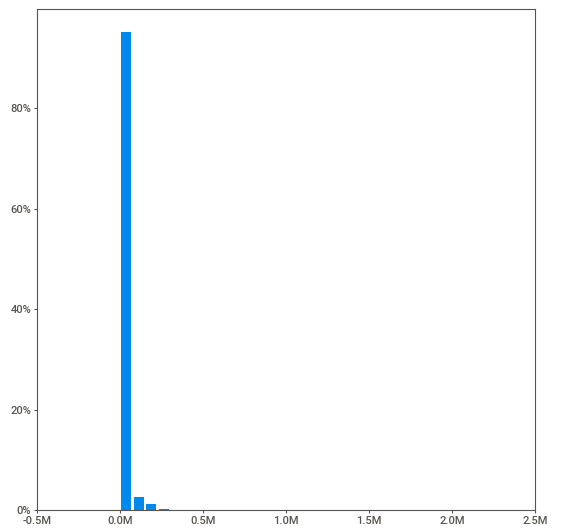
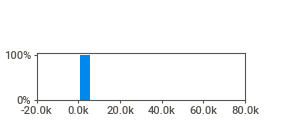
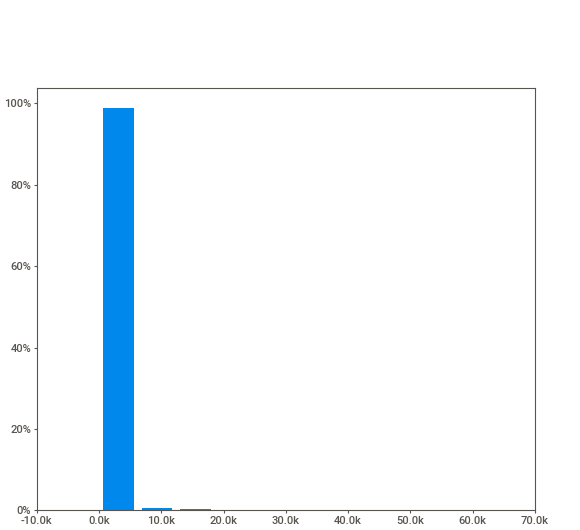
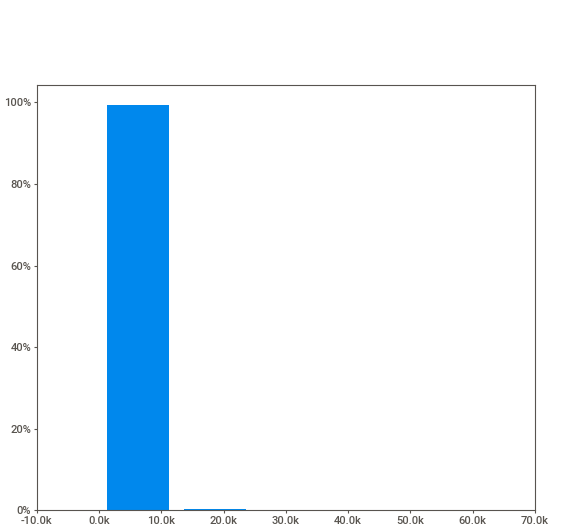
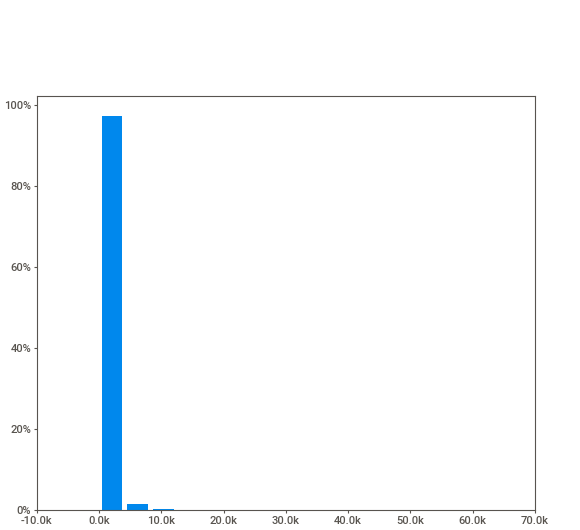
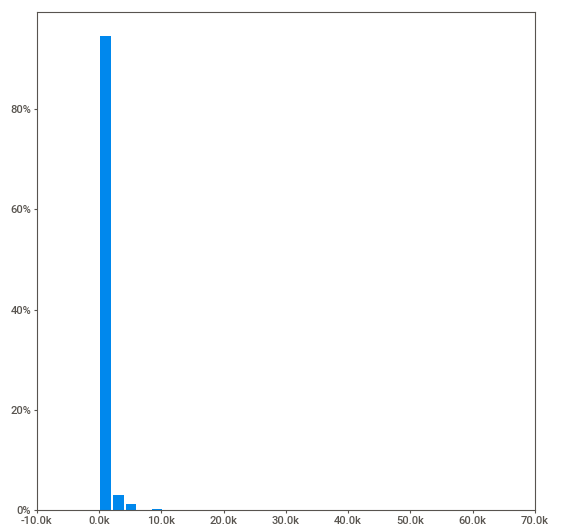
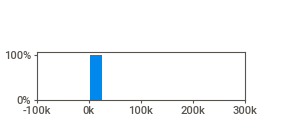
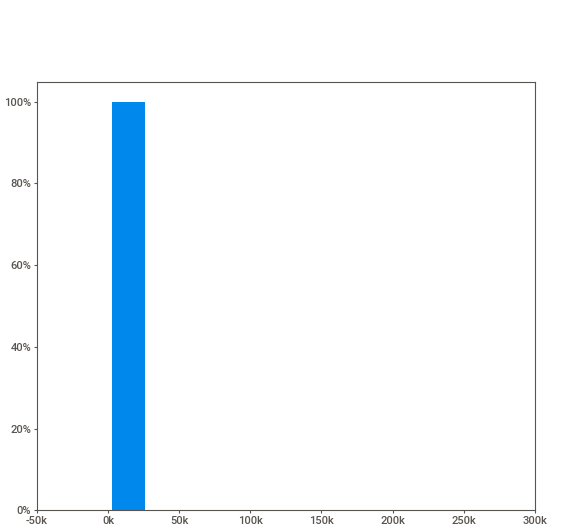
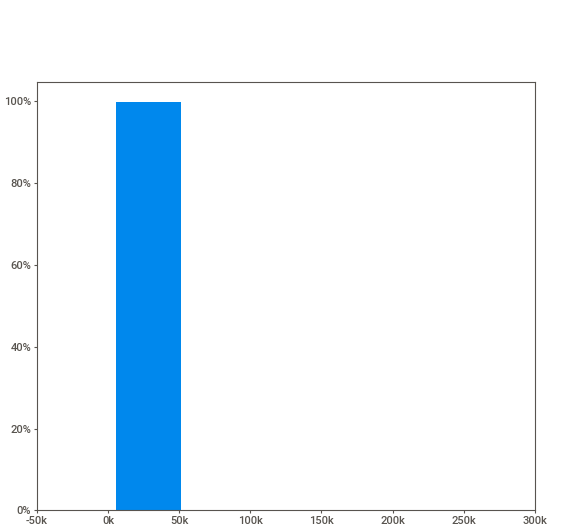
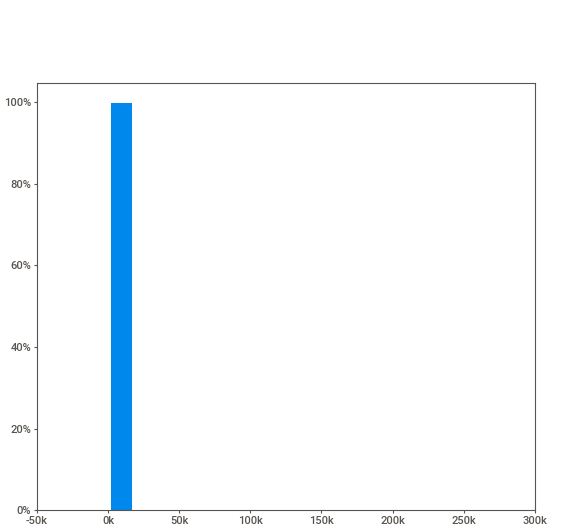
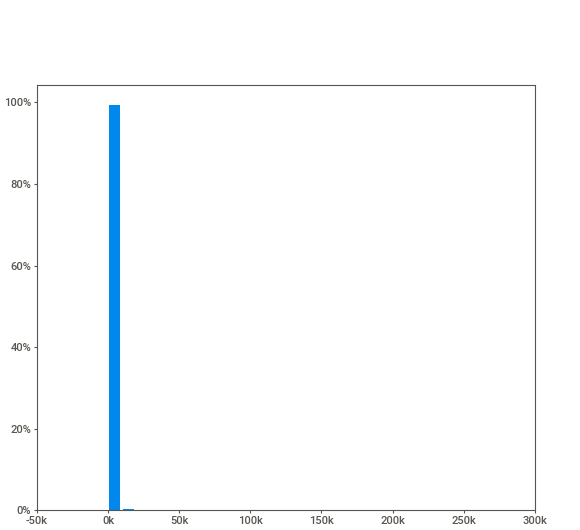
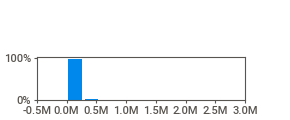
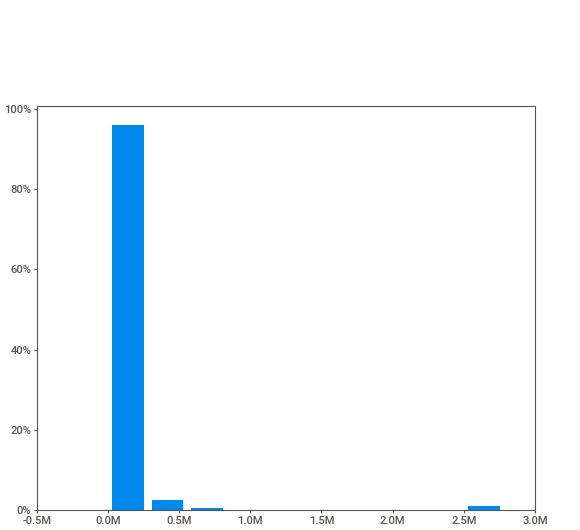
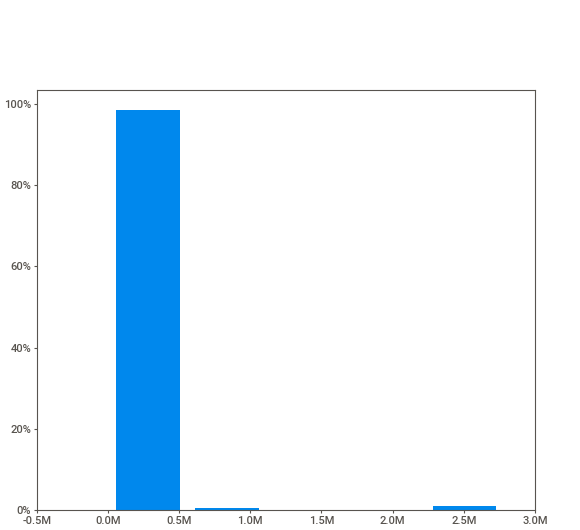
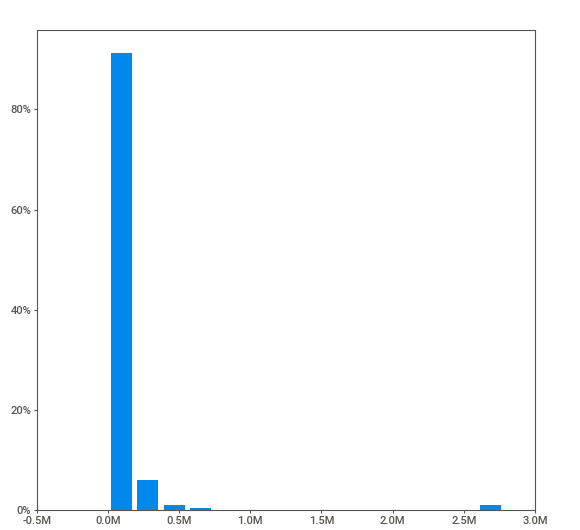
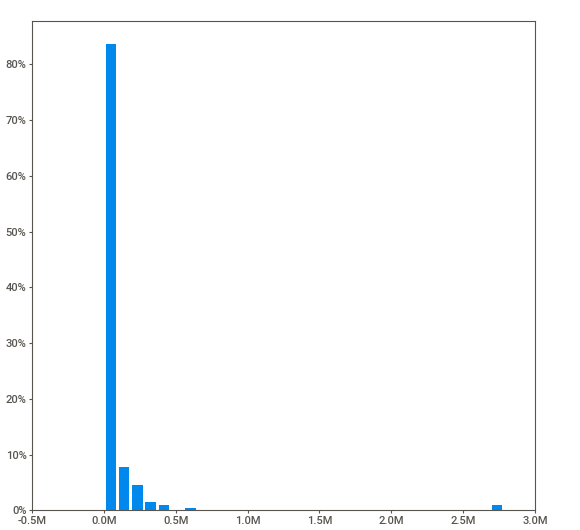
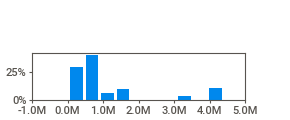
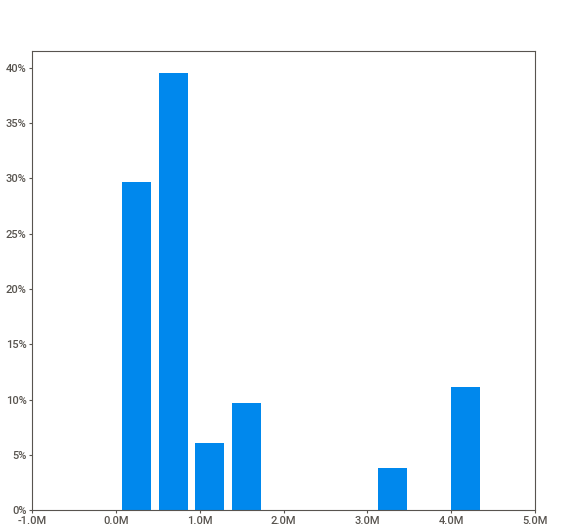
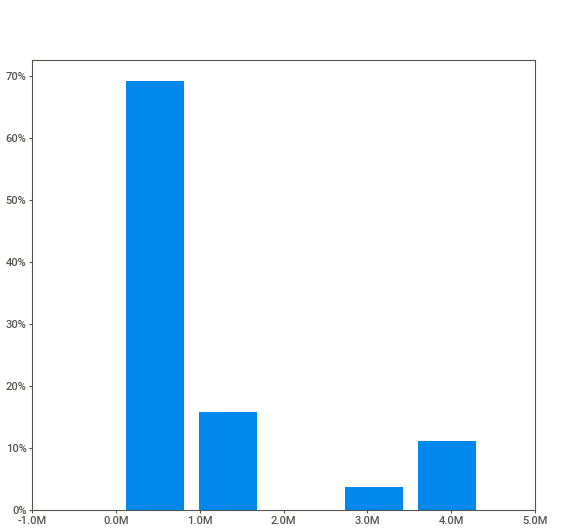
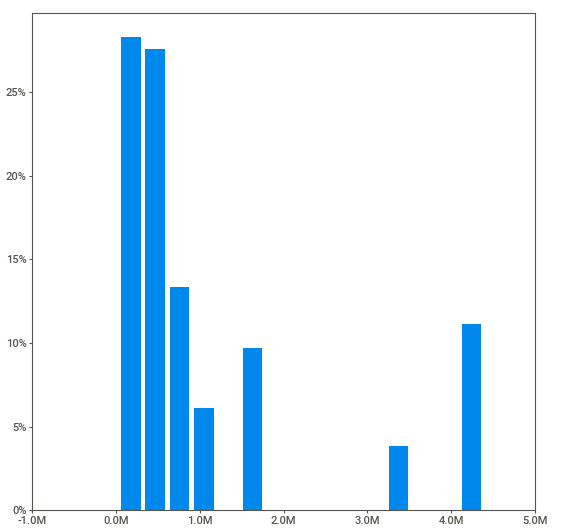
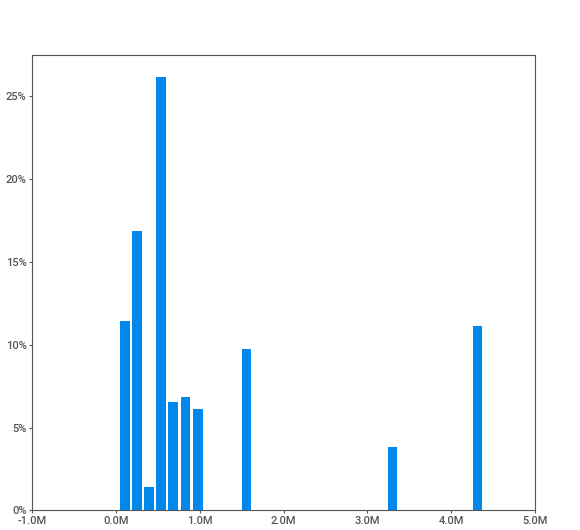
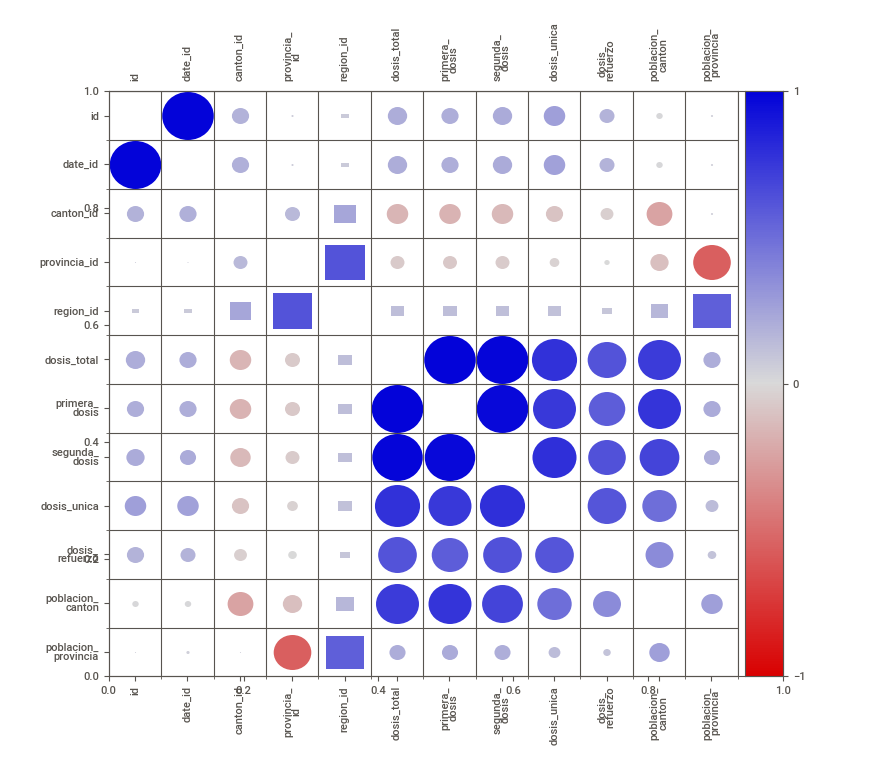
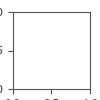

In [40]:
#Reporte 1: fact_vacunacion
# force_num asegura que las columnas de dosis se traten como numéricas
# (por si quedaron como object tras la carga desde CSV)
fc_fact = FeatureConfig(
    force_num=["dosis_total", "primera_dosis", "segunda_dosis",
               "dosis_unica", "dosis_refuerzo",
               "poblacion_canton", "poblacion_provincia"]
)
rep_fact = sv.analyze(df_fact, feat_cfg=fc_fact)
rep_fact.show_html("/content/drive/Shared drives/ETL_final_delivery/" + "sweetviz_fact.html", open_browser=False)
print("Reporte tf_fact guardado en Drive")
rep_fact.show_notebook()

                                             |          | [  0%]   00:00 -> (? left)

Report /content/drive/Shared drives/ETL_final_delivery/sweetviz_covid.html was generated.
Reporte tf_covid guardado en Drive ✓



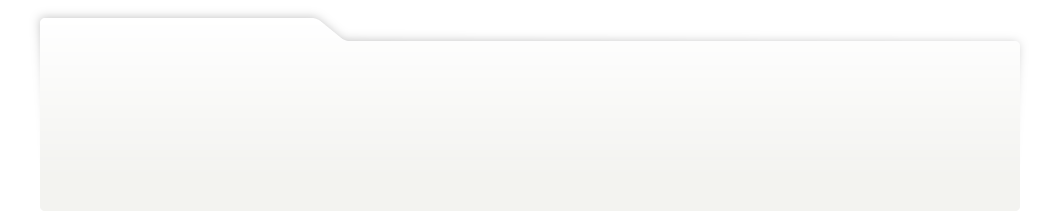
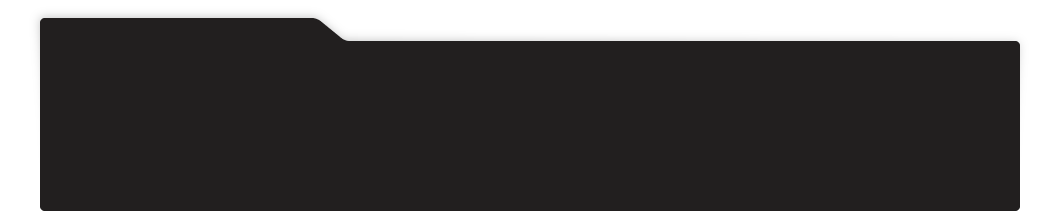
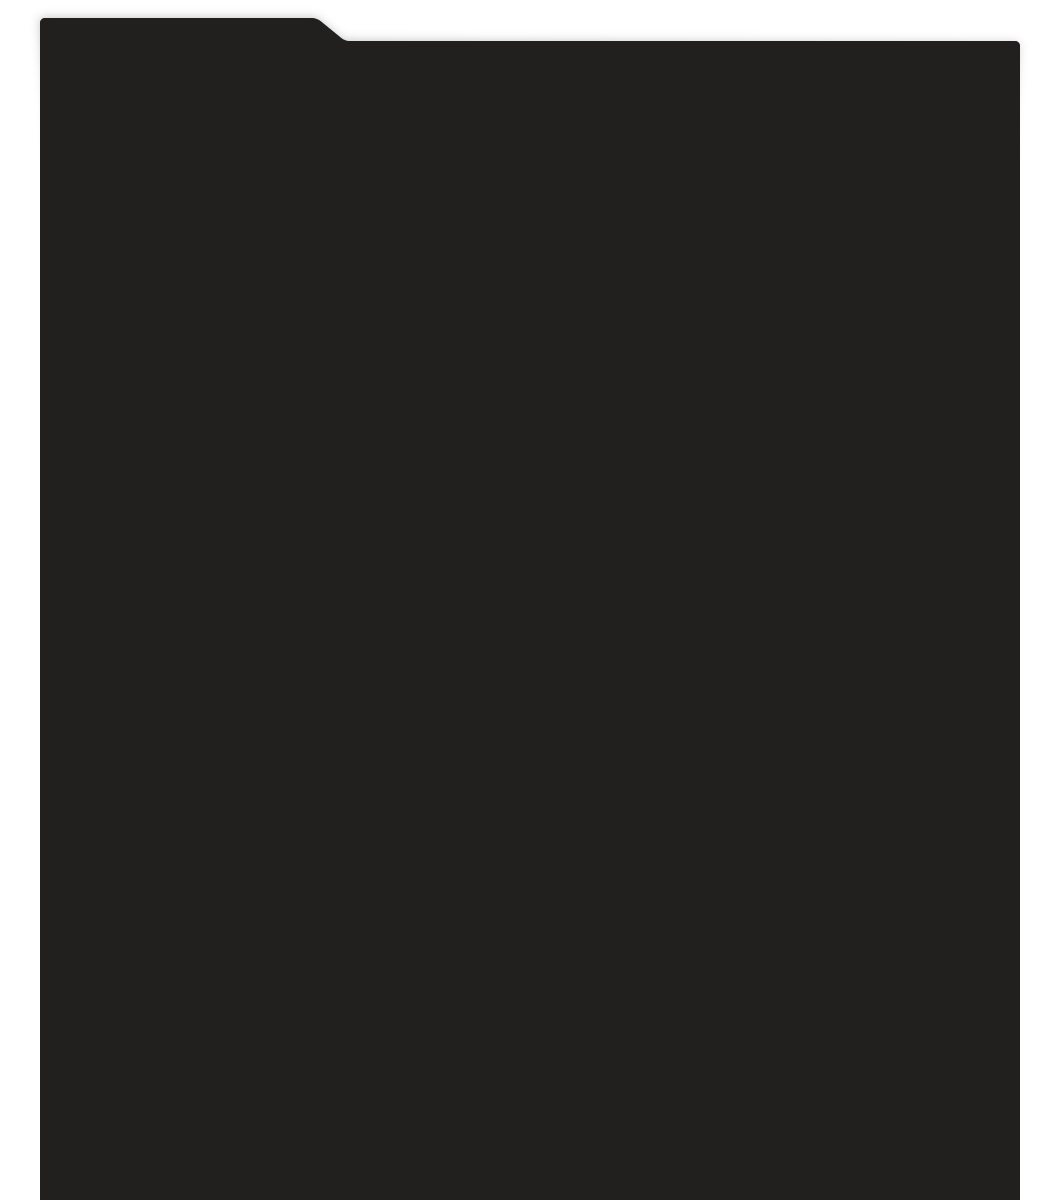
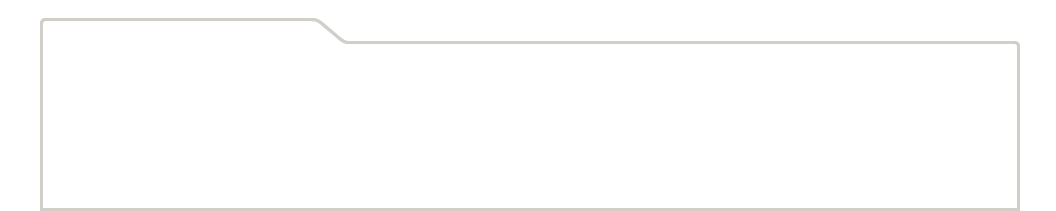
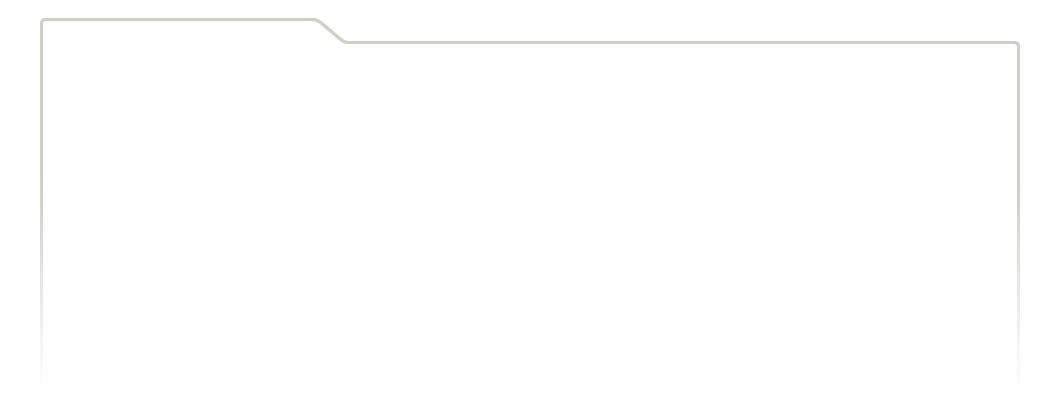
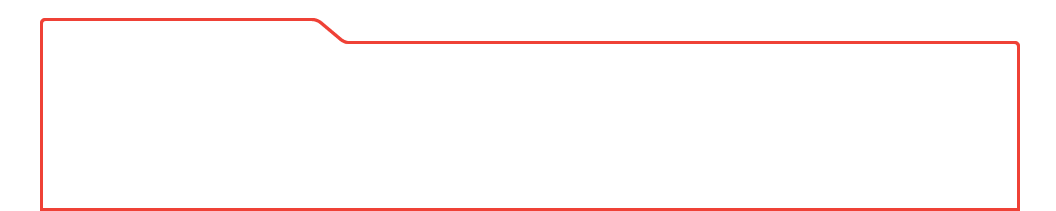
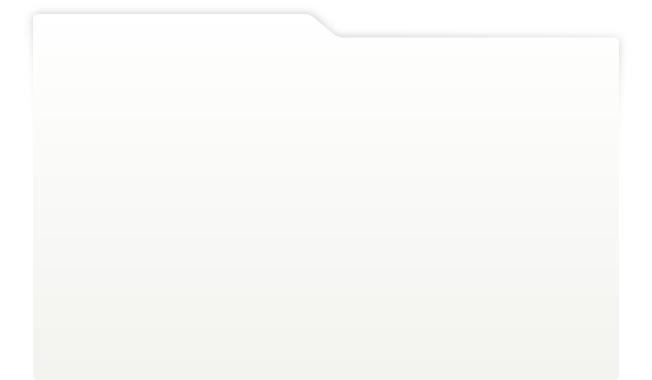
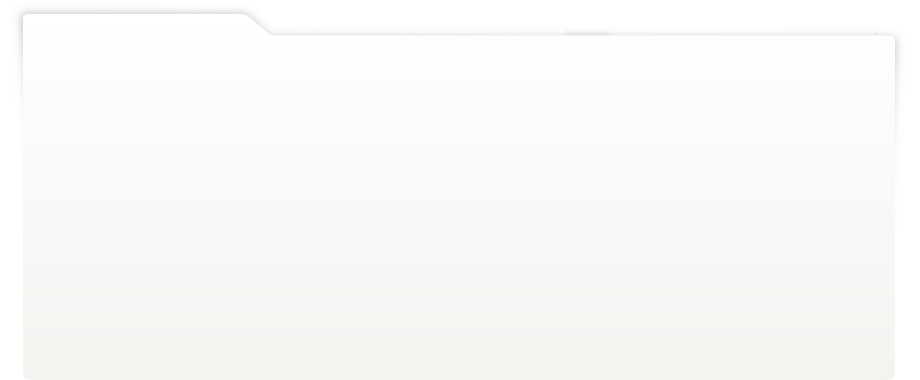
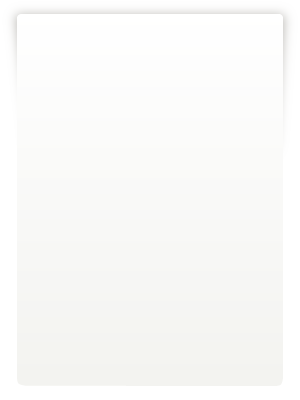
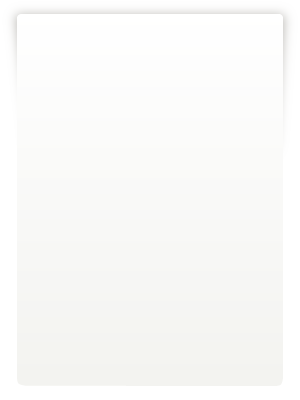
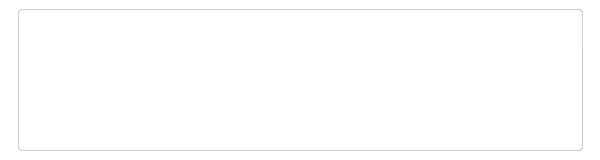
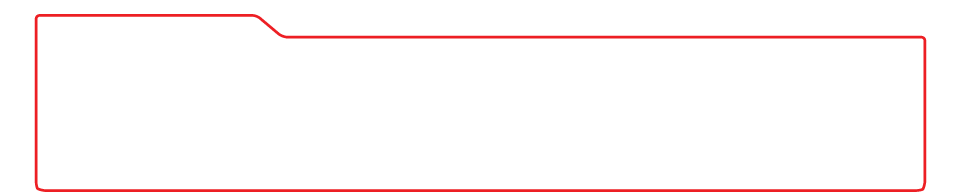
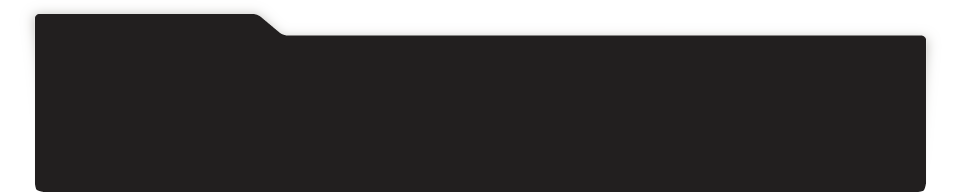
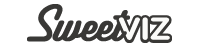
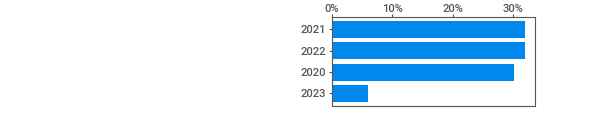
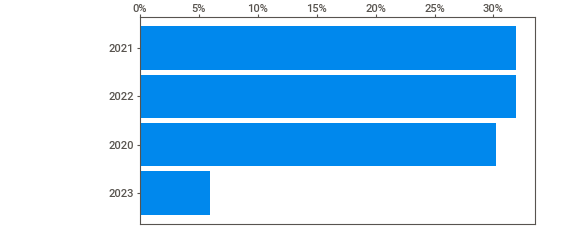
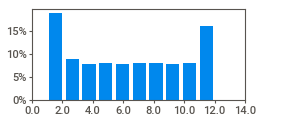
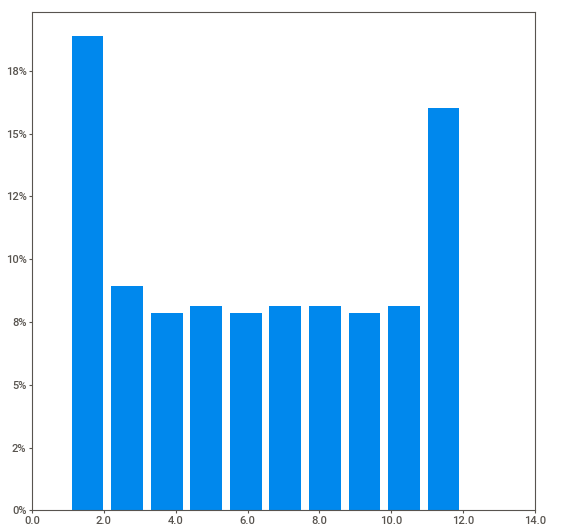
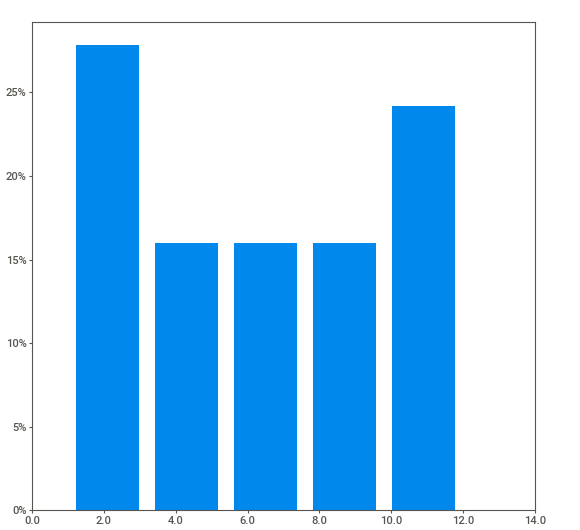
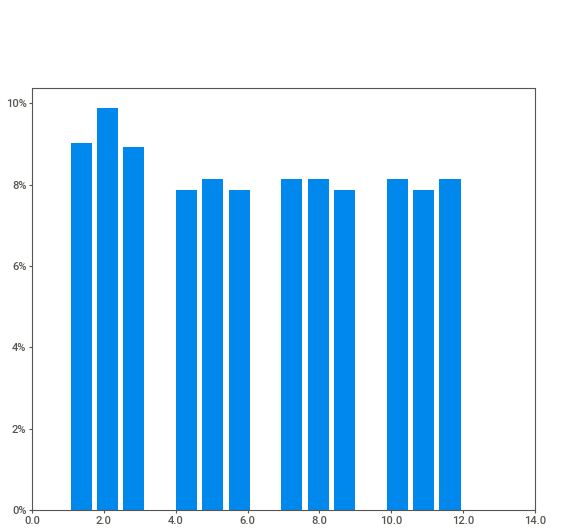
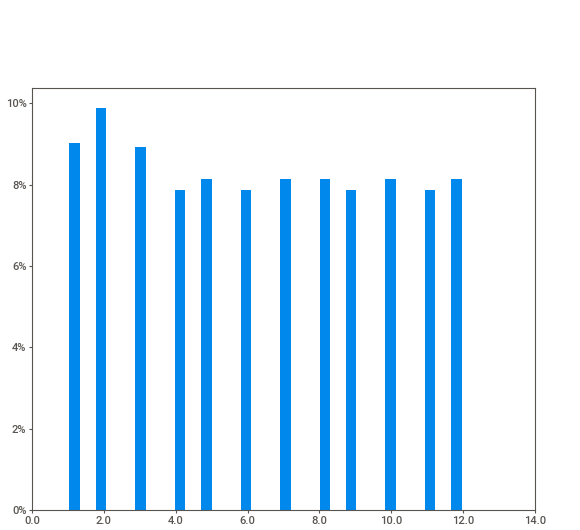
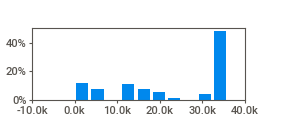
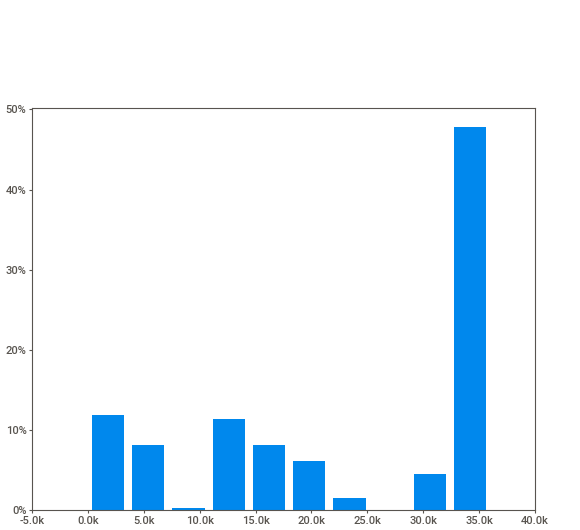
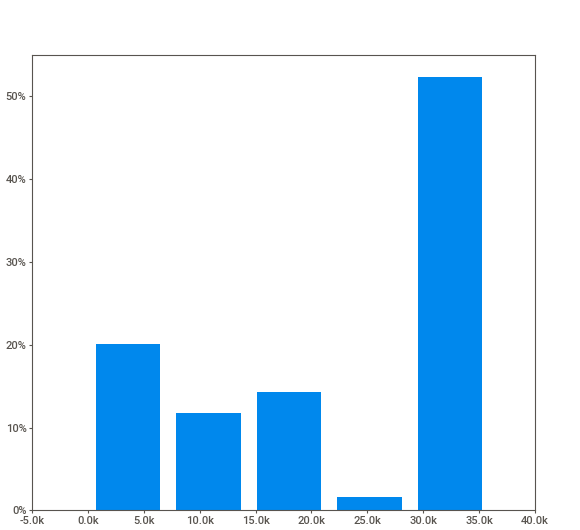
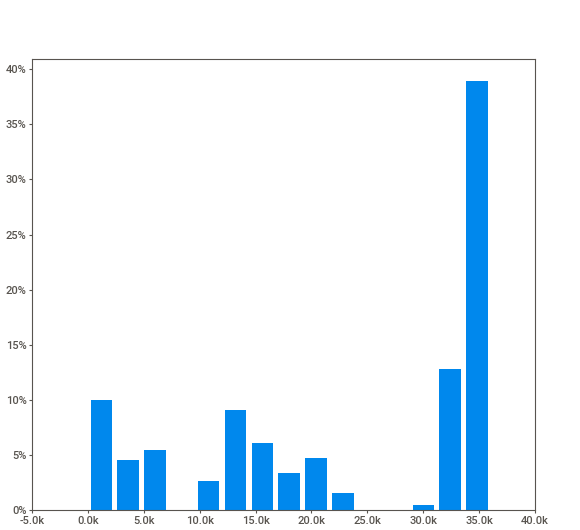
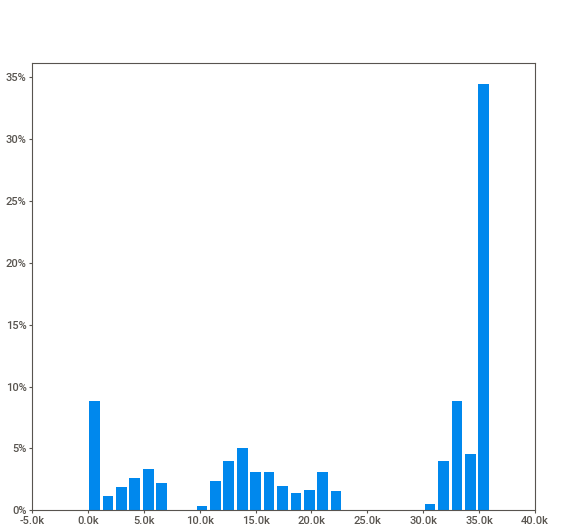
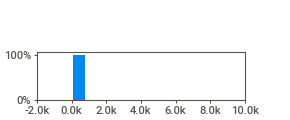
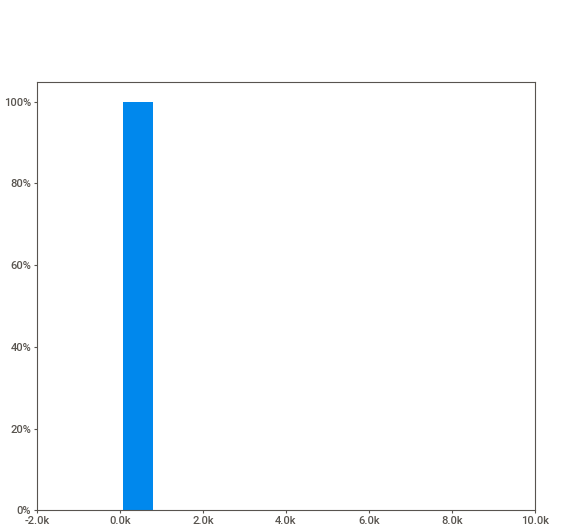
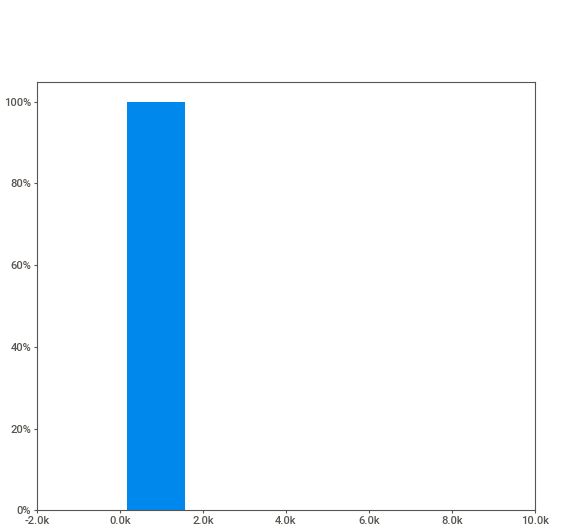
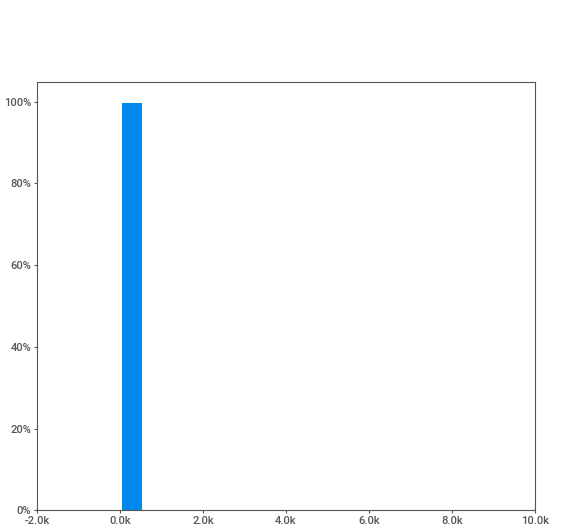
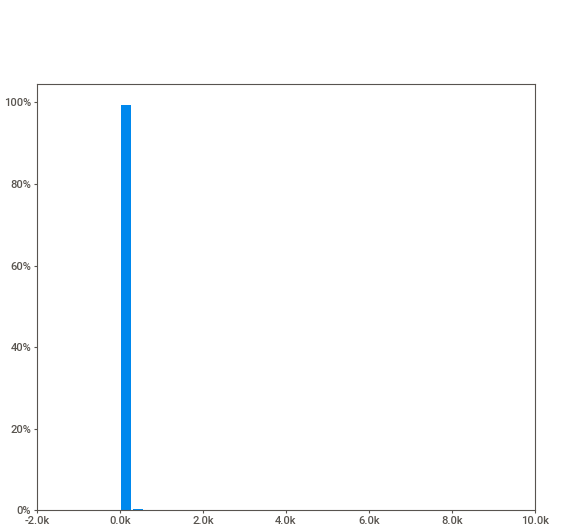
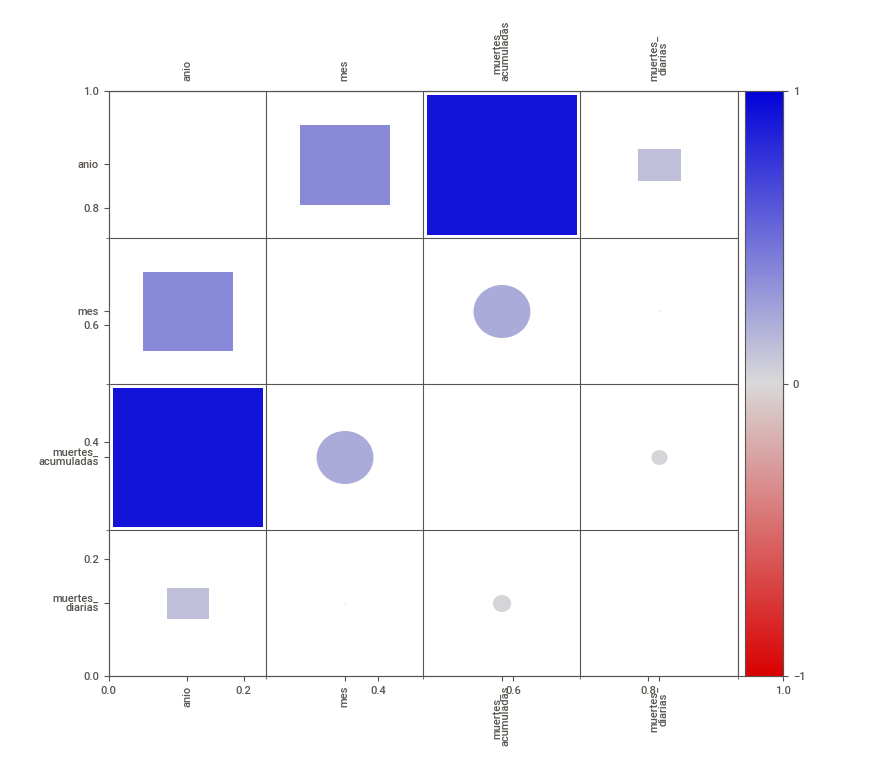
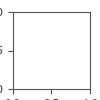

In [41]:
#eeporte 2: covid_deaths_ecuador
rep_covid = sv.analyze(df_covid)
rep_covid.show_html("/content/drive/Shared drives/ETL_final_delivery/" + "sweetviz_covid.html", open_browser=False)
print("Reporte tf_covid guardado en Drive ✓")
rep_covid.show_notebook()

                                             |          | [  0%]   00:00 -> (? left)

Report /content/drive/Shared drives/ETL_final_delivery/sweetviz_uhc.html was generated.
Reporte tf_uhc guardado en Drive ✓



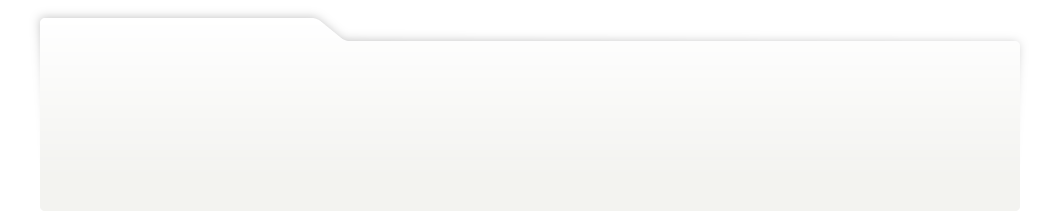
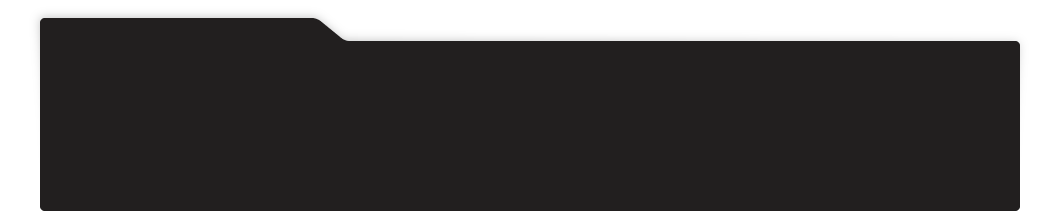
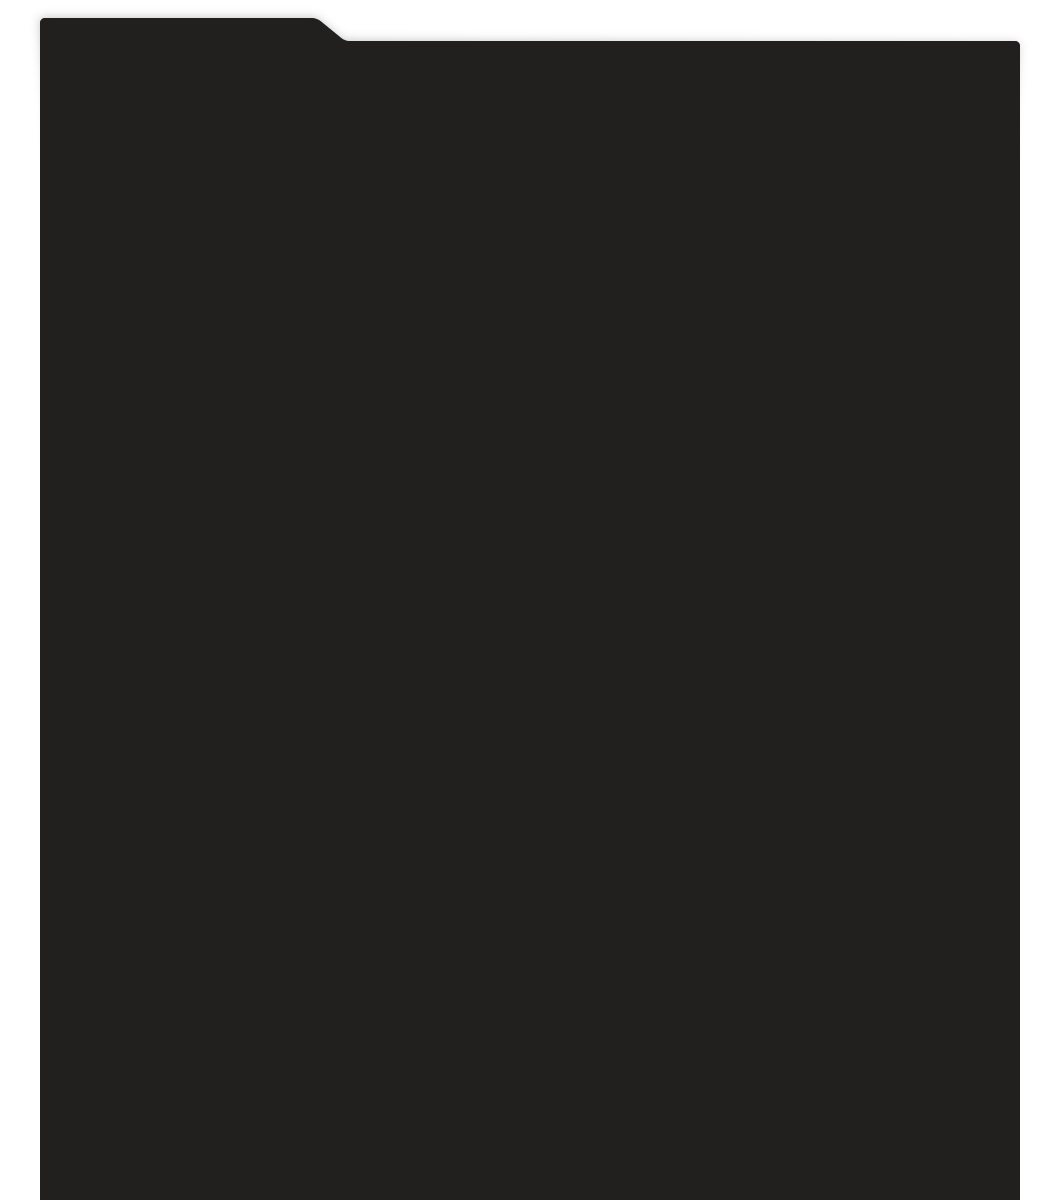
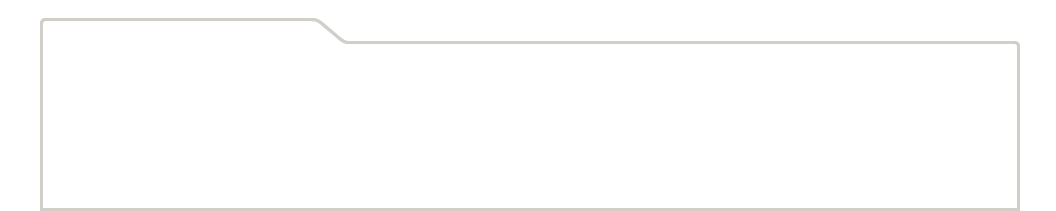
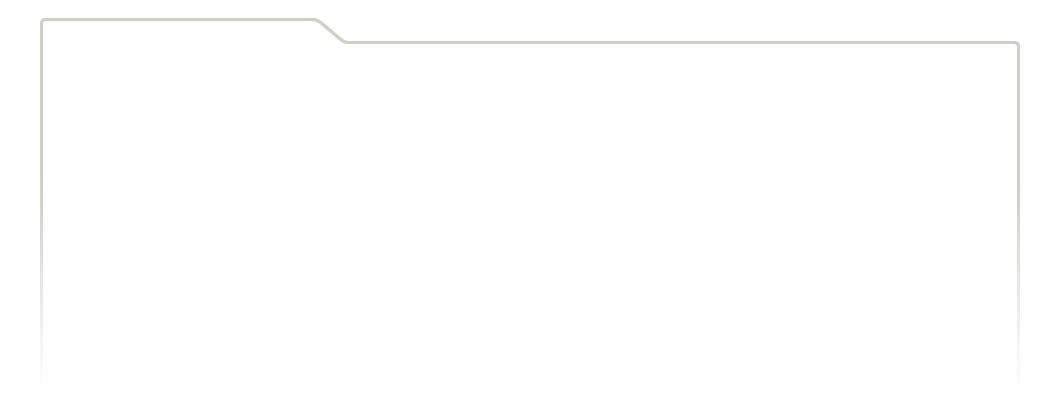
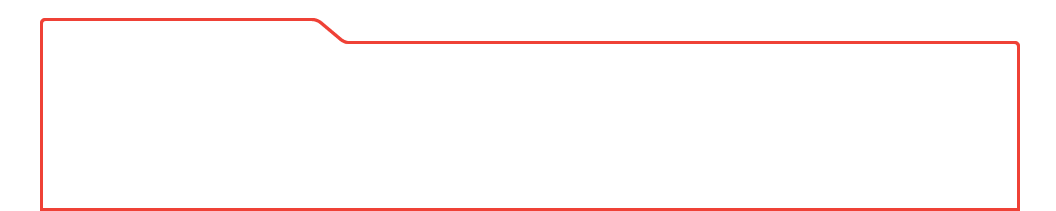
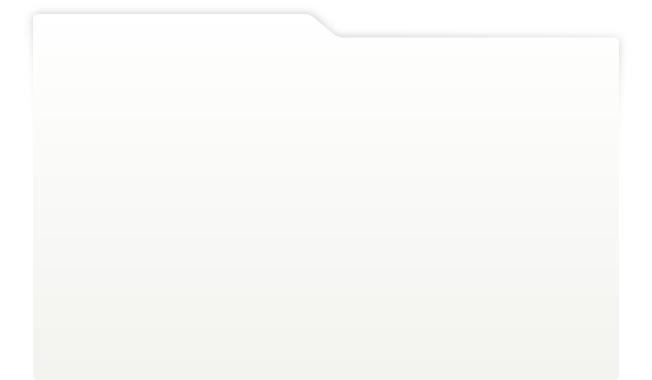
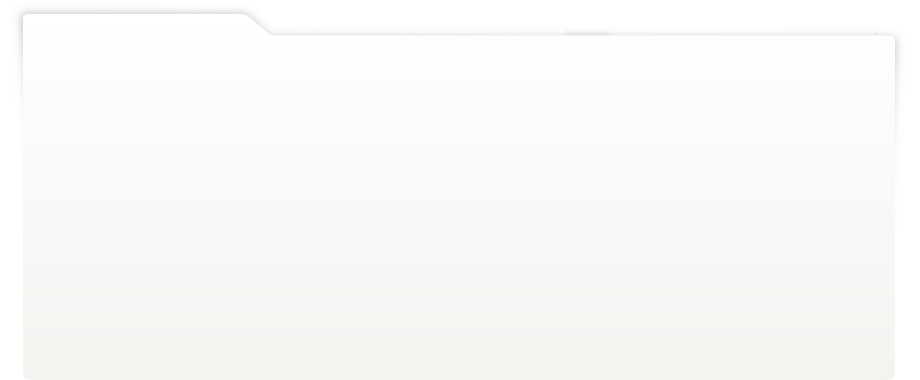
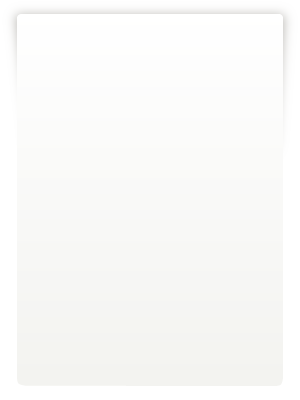
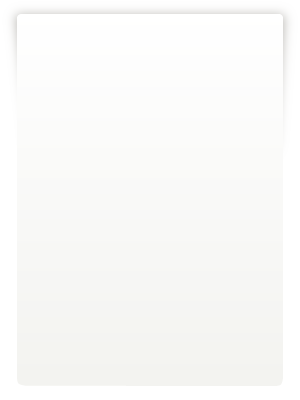
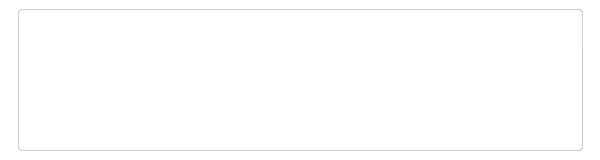
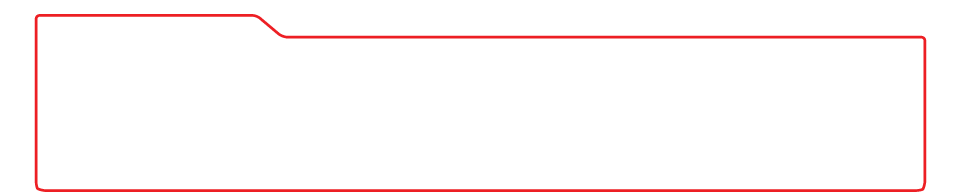
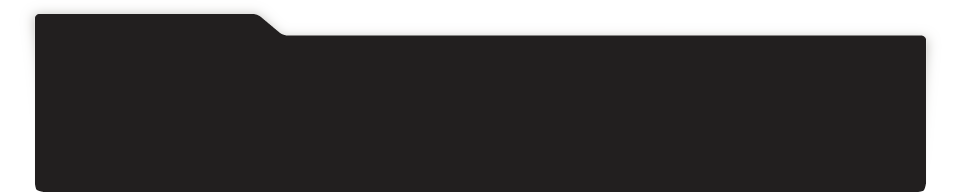
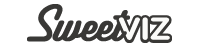
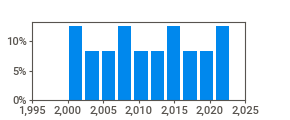
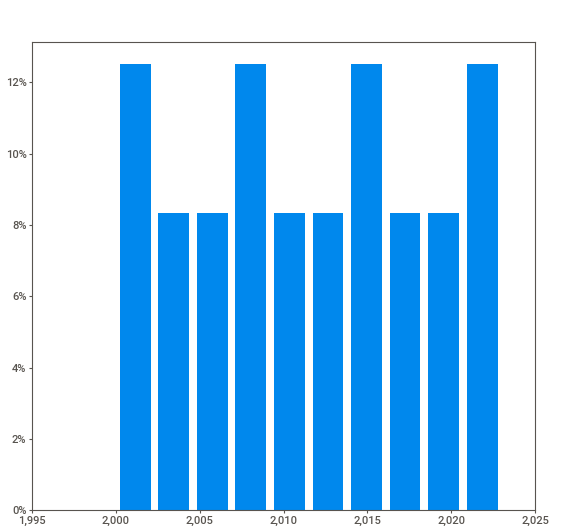
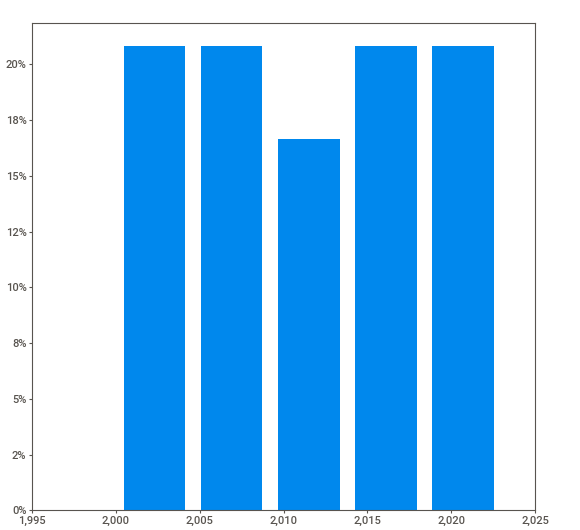
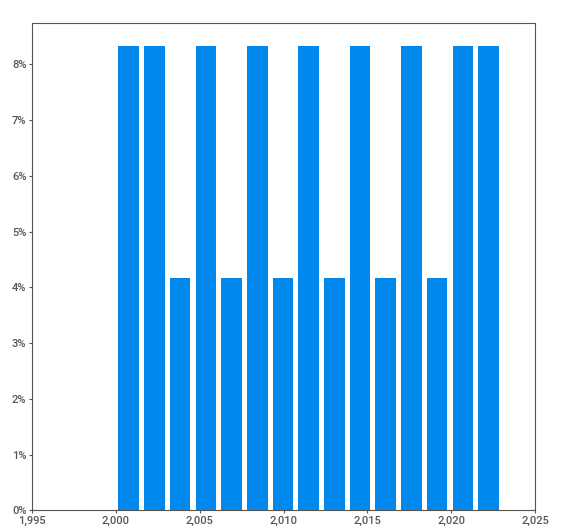
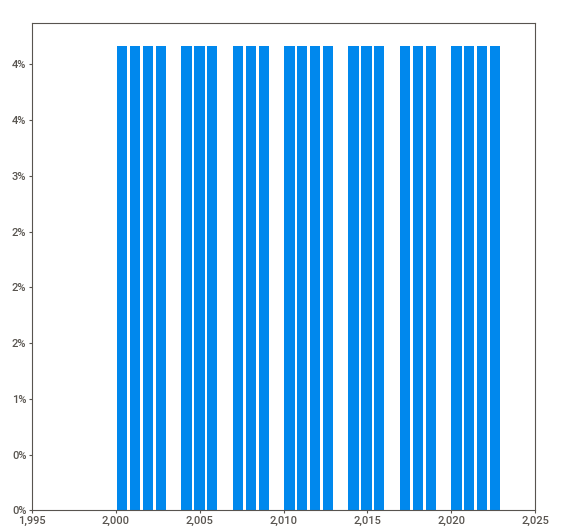
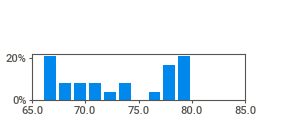
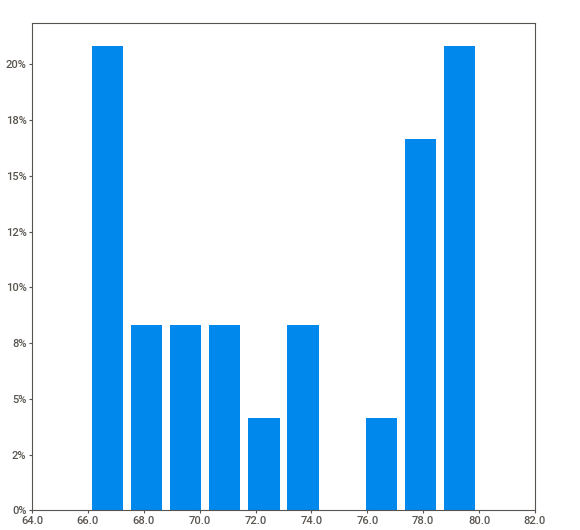
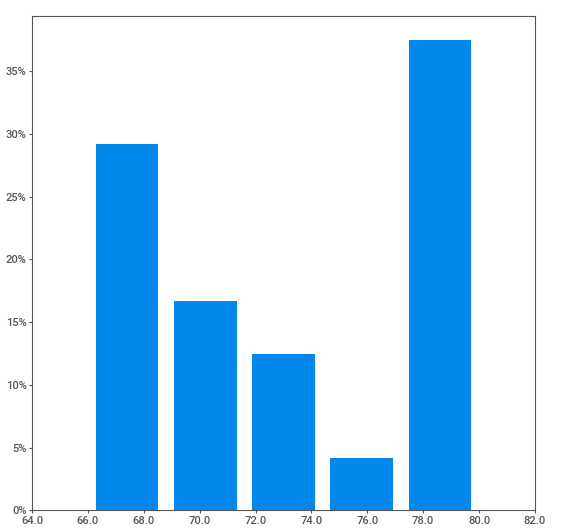
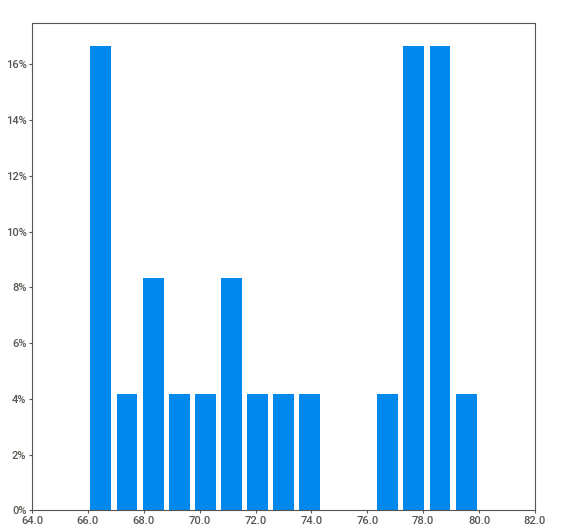
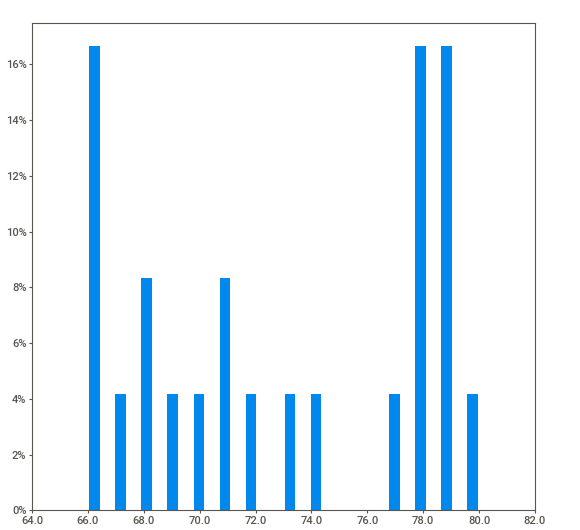
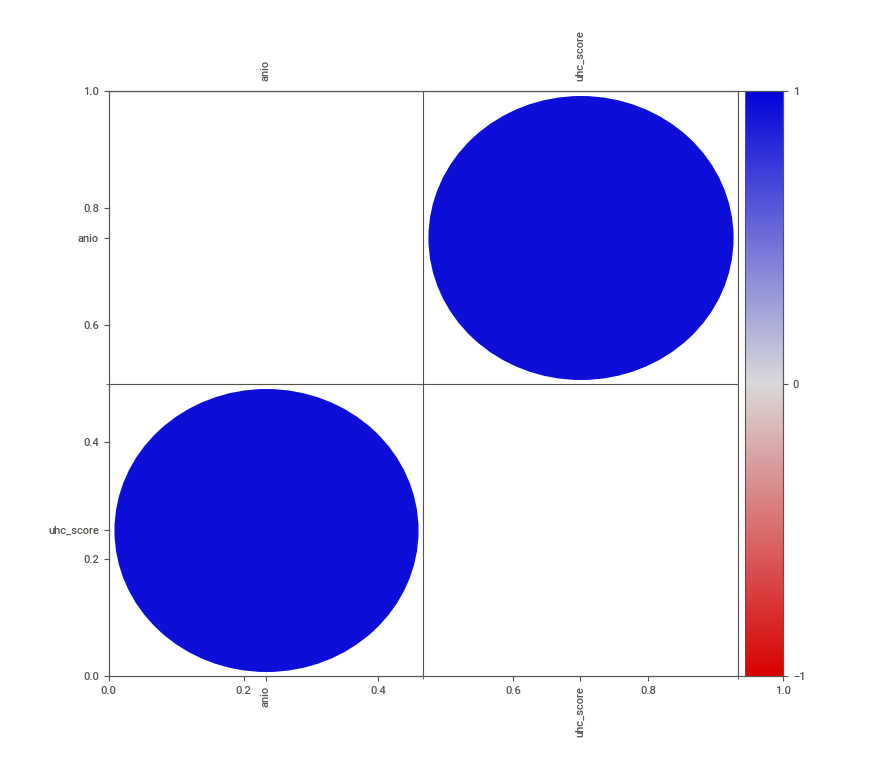
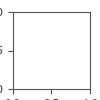

In [42]:
#Reporte 3: uhc_index_ecuador
rep_uhc = sv.analyze(df_uhc)
rep_uhc.show_html("/content/drive/Shared drives/ETL_final_delivery/" + "sweetviz_uhc.html", open_browser=False)
print("Reporte tf_uhc guardado en Drive ✓")
rep_uhc.show_notebook()

---
##Analisis -> Variables de Dosis

Exploramos la distribución de cada tipo de dosis en `tf_fact` mediante histogramas y boxplots.

In [43]:
dosis_cols = ["dosis_total", "primera_dosis", "segunda_dosis",
              "dosis_unica", "dosis_refuerzo"]

# Estadisticas descriptivas
print("\n Estadisticas descriptivas — variables de dosis")
print(df_fact[dosis_cols].describe().applymap(lambda x: f"{x:,.0f}"))


 Estadisticas descriptivas — variables de dosis
      dosis_total primera_dosis segunda_dosis dosis_unica dosis_refuerzo
count      66,320        66,320        66,320      66,320         66,320
mean       57,080        32,700        23,314         589            477
std       263,230       142,360       117,318       3,198          5,388
min             1             0             0           0              0
25%         2,777         2,040           554           0              0
50%        12,546         7,942         3,888           0              0
75%        39,195        23,158        15,134         180              0
max     4,956,326     2,337,173     2,283,263      61,994        286,080


---
##Análisis Temporal COVID-19

Visualizacion la evolución de muertes COVID en el tiempo.

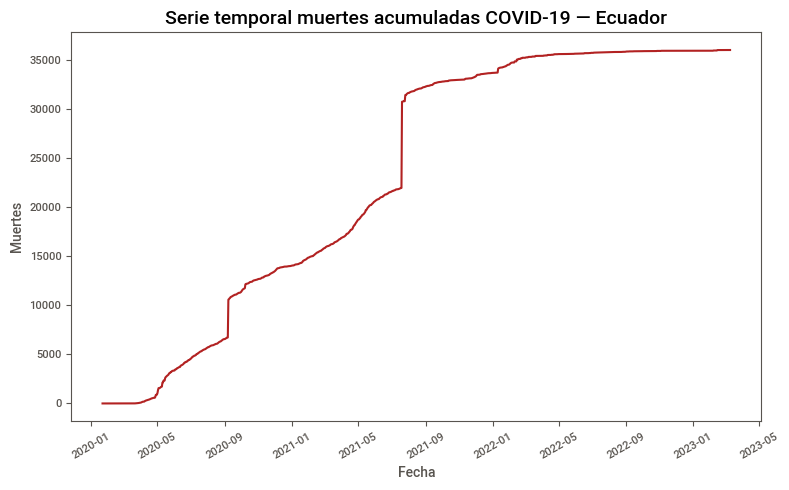

Serie temporal COVID guardada


In [44]:
df_cv = df_covid.copy()
df_cv["fecha"] = pd.to_datetime(df_cv["fecha"])

plt.figure(figsize=(8, 5))
plt.title("Serie temporal muertes acumuladas COVID-19 — Ecuador", fontsize=14, fontweight="bold")

# Muertes acumuladas
plt.plot(df_cv["fecha"], df_cv["muertes_acumuladas"],
         color="firebrick", linewidth=1.5)
plt.xticks(rotation=30)
plt.xlabel("Fecha")
plt.ylabel("Muertes")

plt.tight_layout()
plt.savefig(ruta + "eda_covid_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()
print("Serie temporal COVID guardada")

---
##UHC Score - Evolución del Índice de Cobertura Sanitaria

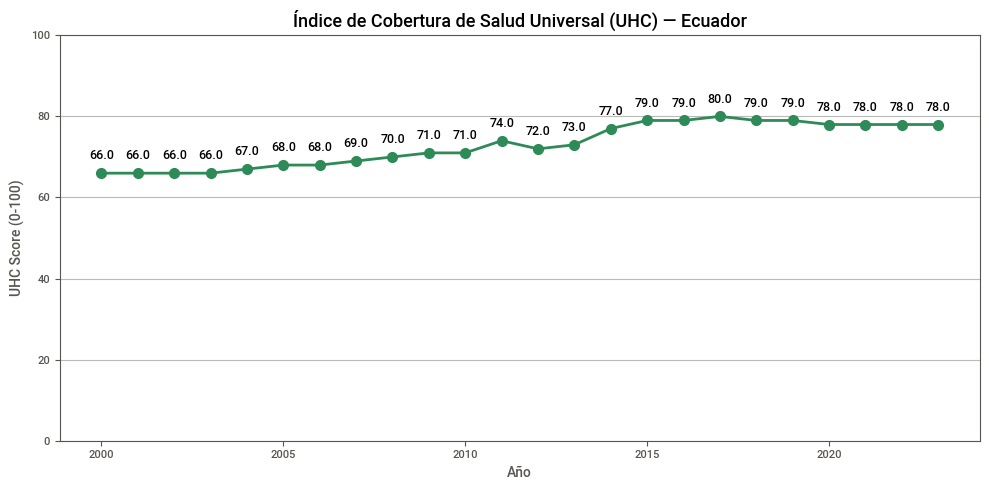

Gráfico UHC Score guardado

Último año disponible: 2023
Último UHC Score: 78.0
Tendencia: variable


In [45]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_uhc["anio"], df_uhc["uhc_score"],
        marker="o", color="seagreen", linewidth=2, markersize=7)

# Añadir etiquetas de valor
for _, row in df_uhc.iterrows():
    ax.annotate(f"{row['uhc_score']:.1f}",
                (row["anio"], row["uhc_score"]),
                textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=9)

ax.set_title("Índice de Cobertura de Salud Universal (UHC) — Ecuador",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Año")
ax.set_ylabel("UHC Score (0-100)")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig(ruta + "eda_uhc_score.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico UHC Score guardado")

print(f"\nÚltimo año disponible: {df_uhc['anio'].max()}")
print(f"Último UHC Score: {df_uhc.loc[df_uhc['anio'].idxmax(), 'uhc_score']:.1f}")
print(f"Tendencia: {'creciente ↑' if df_uhc['uhc_score'].is_monotonic_increasing else 'variable'}")

# Distribucion y boxplot

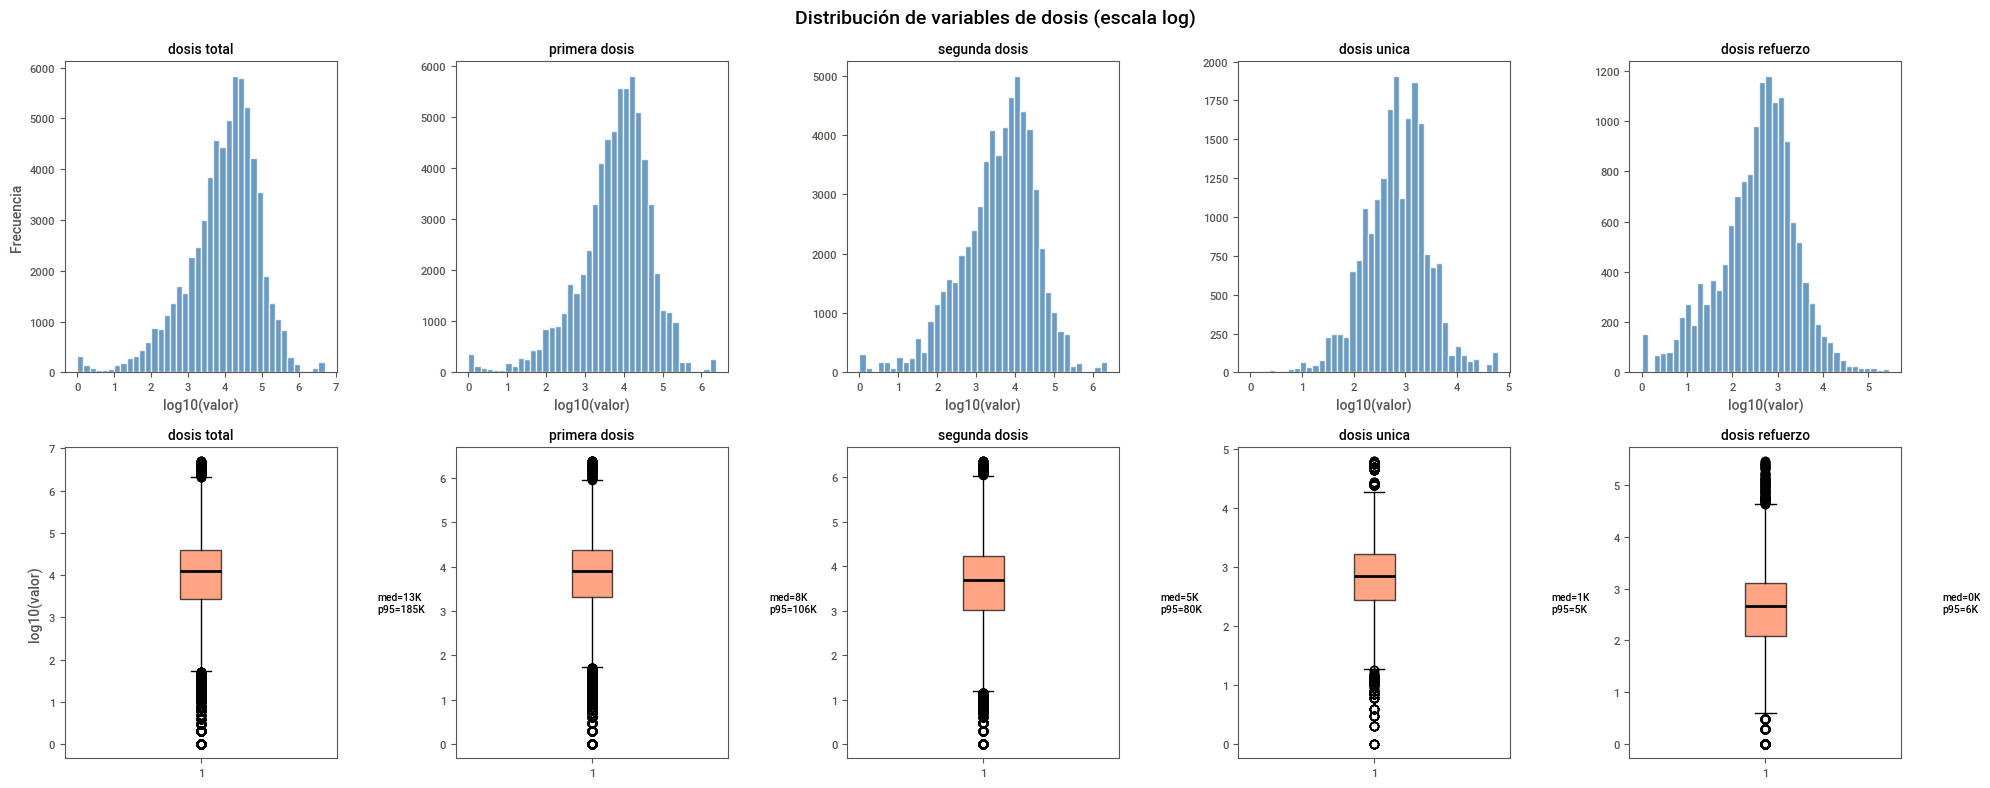

Distribuciones guardadas


In [46]:
dosis_cols = ["dosis_total","primera_dosis","segunda_dosis","dosis_unica","dosis_refuerzo"]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle("Distribución de variables de dosis (escala log)",
             fontsize=14, fontweight="bold")

for i, col in enumerate(dosis_cols):
    serie = df_fact[col][df_fact[col] > 0]  # log requiere > 0

    # Histograma log
    axes[0, i].hist(np.log10(serie), bins=40, color="steelblue", edgecolor="white", alpha=0.8)
    axes[0, i].set_title(col.replace("_", " "), fontsize=10)
    axes[0, i].set_xlabel("log10(valor)")
    axes[0, i].set_ylabel("Frecuencia" if i == 0 else "")

    # Boxplot log
    axes[1, i].boxplot(np.log10(serie), patch_artist=True,
                       boxprops=dict(facecolor="coral", alpha=0.7),
                       medianprops=dict(color="black", linewidth=2))
    axes[1, i].set_title(col.replace("_", " "), fontsize=10)
    axes[1, i].set_ylabel("log10(valor)" if i == 0 else "")

    # Anotar mediana y p95
    med = serie.median()
    p95 = serie.quantile(0.95)
    axes[1, i].annotate(f"med={med/1e3:.0f}K\np95={p95/1e3:.0f}K",
                        xy=(1.15, 0.5), xycoords="axes fraction",
                        fontsize=7.5, va="center")

plt.tight_layout()
plt.savefig(ruta + "eda_distribuciones_dosis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Distribuciones guardadas")


# **Dashboard Estatico**

In [47]:
ruta_dwh_final_delivery = "/content/drive/Shared drives/ETL_final_delivery/dwh_final_delivery.db"

-Total dosis

In [48]:
import sqlite3

conn = sqlite3.connect(ruta_dwh_final_delivery)

total = conn.execute("""
    SELECT SUM(max_dosis) AS total_pais
    FROM (
        SELECT canton_id, MAX(dosis_total) AS max_dosis
        FROM fact_vacunacion
        GROUP BY canton_id
    ) t
""").fetchone()[0]

conn.close()

print(f"Total de dosis aplicadas en Ecuador 2021: {total:,}")

Total de dosis aplicadas en Ecuador 2021: 27,531,685


-Dashboard

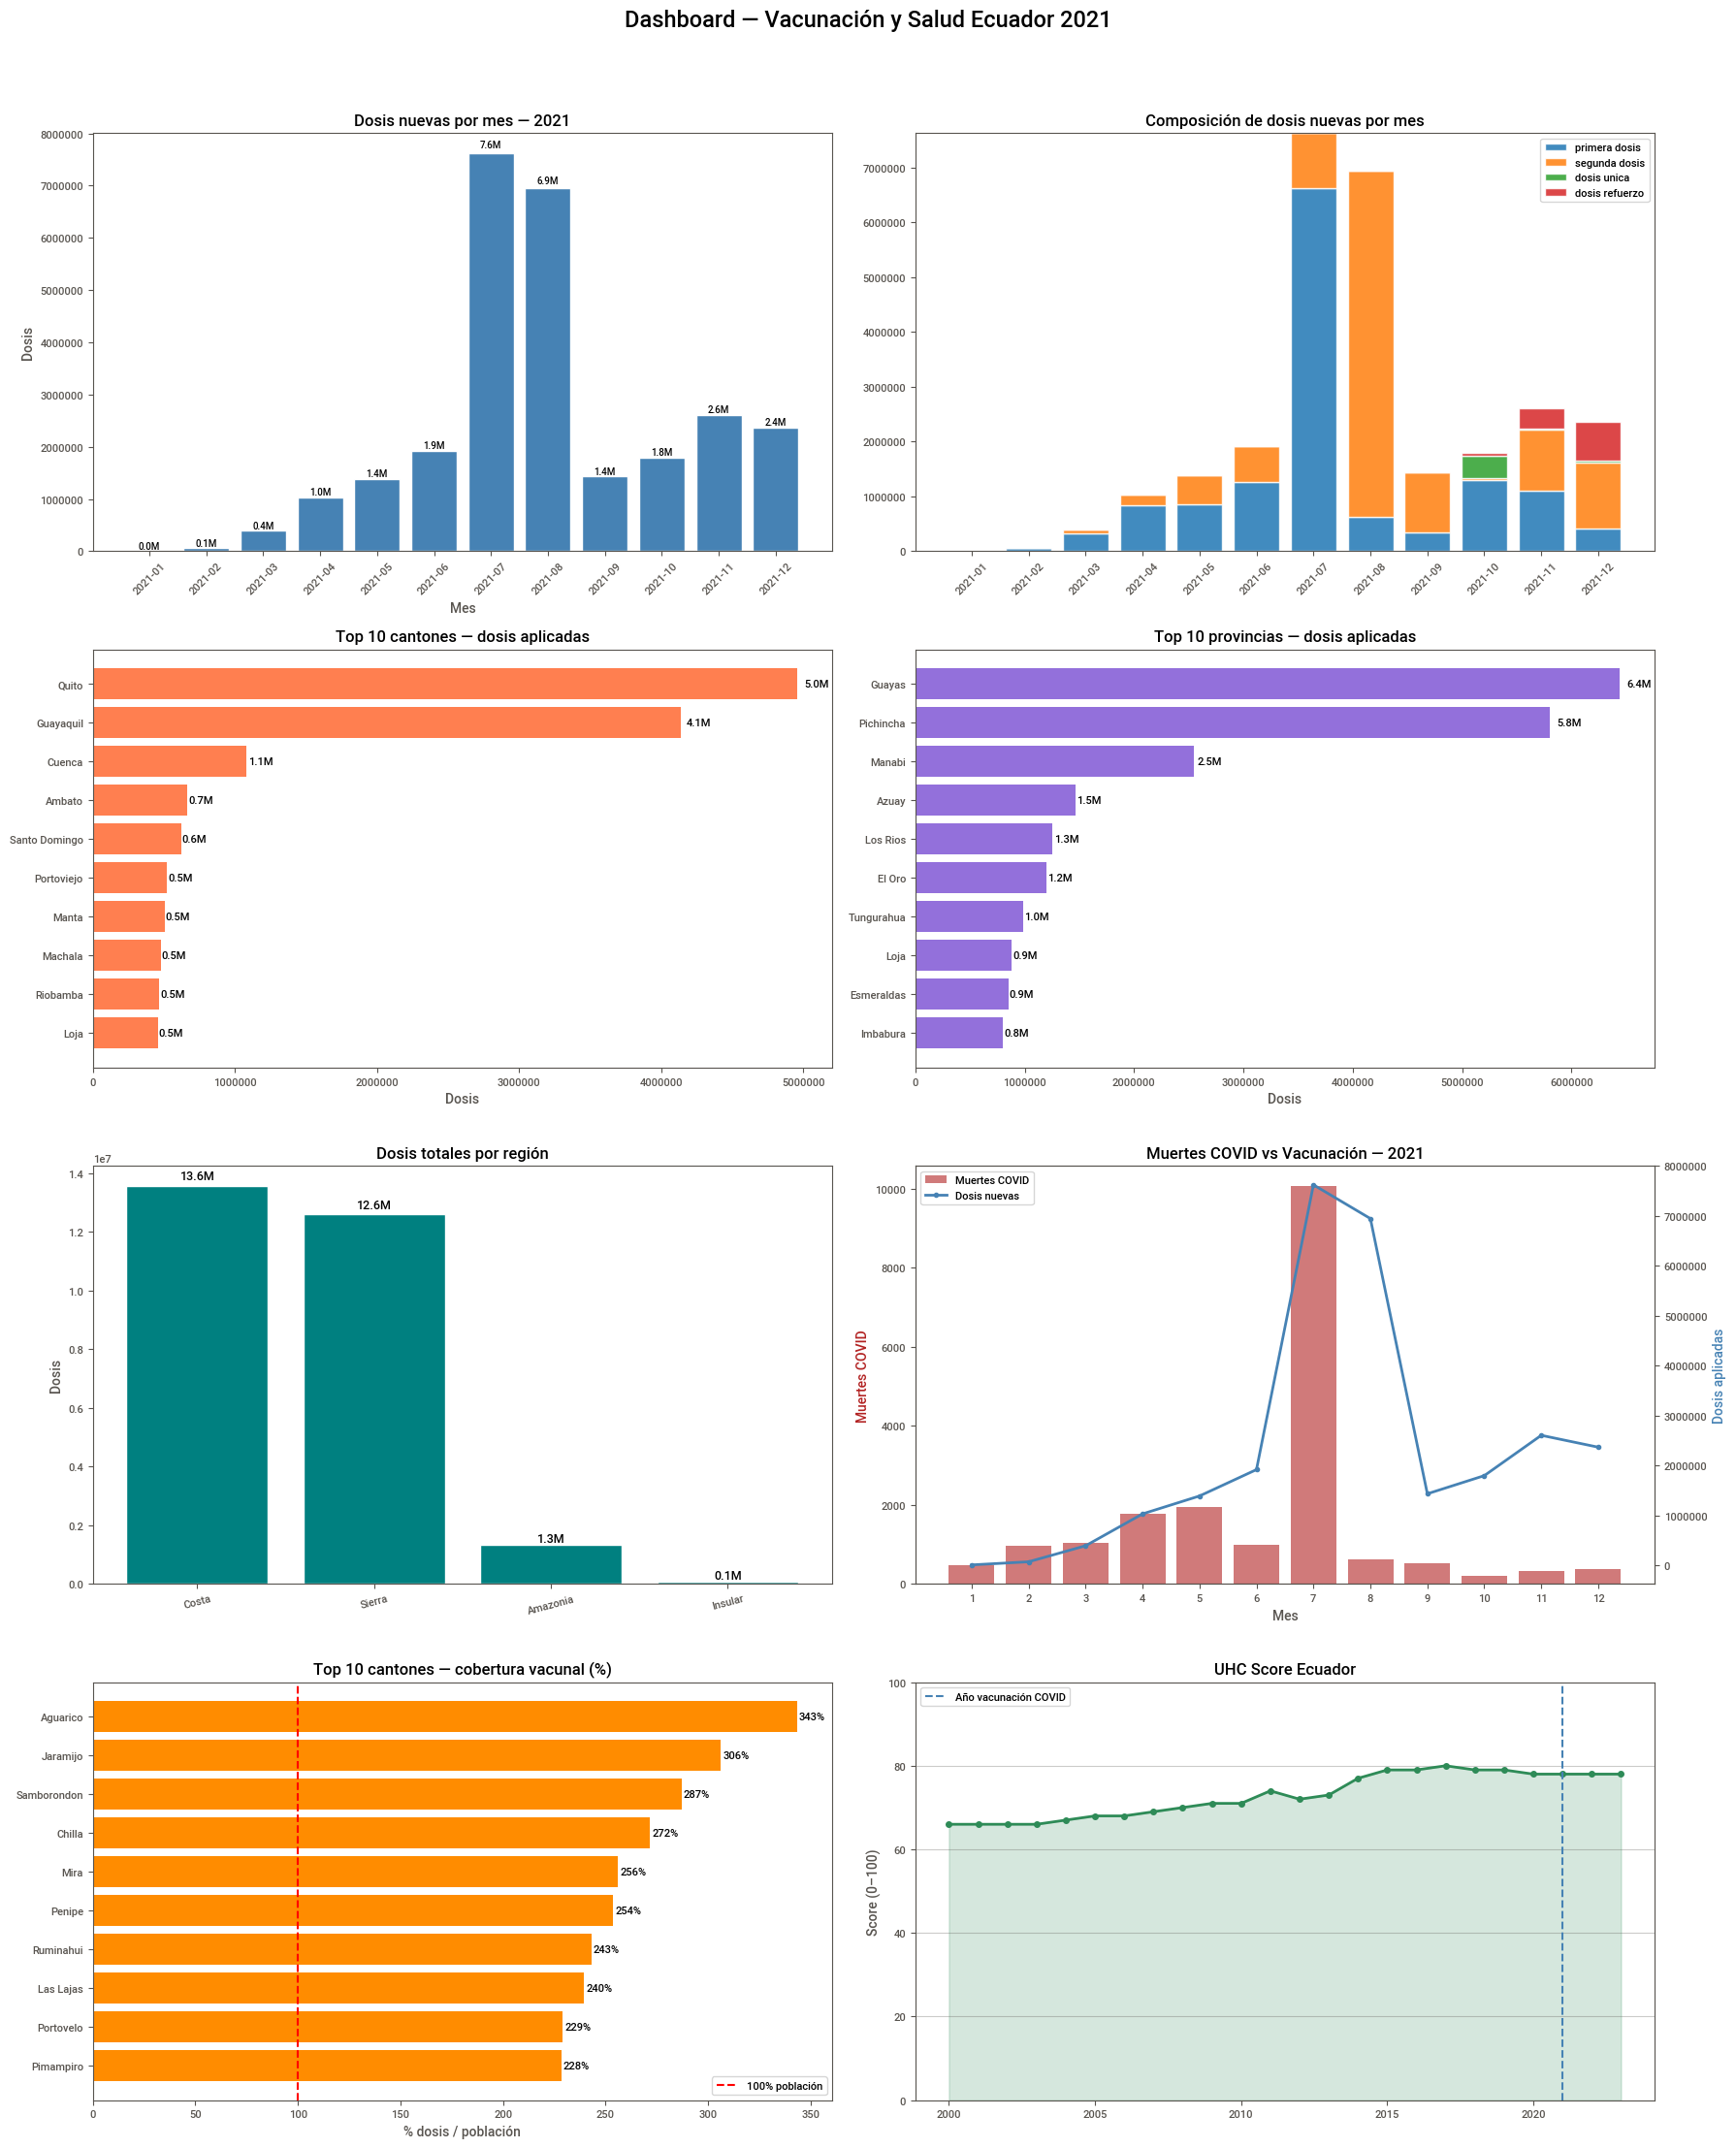

Dashboard generado correctamente.


In [49]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sqlite3

conn = sqlite3.connect(ruta_dwh_final_delivery)

conn.executescript("""
    CREATE INDEX IF NOT EXISTS idx_fv_date   ON fact_vacunacion(date_id);
    CREATE INDEX IF NOT EXISTS idx_fv_canton ON fact_vacunacion(canton_id);
    CREATE INDEX IF NOT EXISTS idx_df_fecha  ON dim_fecha(id, anio, mes, dia);
""")

df_raw = pd.read_sql("""
    SELECT
        d.anio, d.mes, d.dia,
        f.canton_id,
        f.provincia_id,
        f.region_id,
        f.primera_dosis,
        f.segunda_dosis,
        f.dosis_unica,
        f.dosis_refuerzo,
        f.dosis_total,
        f.poblacion_canton
    FROM fact_vacunacion f
    JOIN dim_fecha d ON f.date_id = d.id
    WHERE d.anio = 2021
""", conn)

dim_canton  = pd.read_sql("SELECT canton_id, canton_nombre FROM dim_canton", conn)
dim_prov    = pd.read_sql("SELECT id AS provincia_id, provincia_nombre FROM dim_provincia", conn)
dim_region  = pd.read_sql("SELECT id AS region_id, region_nombre FROM dim_region", conn)
df_uhc_hist = pd.read_sql("SELECT anio, uhc_score FROM dim_indice_uhc ORDER BY anio", conn)
df_covid_m  = pd.read_sql("""
    SELECT d.mes, SUM(f.muertes_diarias) AS muertes
    FROM fact_decesos f
    JOIN dim_fecha d ON f.date_id = d.id
    WHERE d.anio = 2021
    GROUP BY d.mes ORDER BY d.mes
""", conn)

conn.close()


COLS_DOSIS = ["primera_dosis", "segunda_dosis", "dosis_unica", "dosis_refuerzo", "dosis_total"]

# Último día disponible por (canton × mes)
df_ultimo = (
    df_raw
    .sort_values(["canton_id", "anio", "mes", "dia"])
    .groupby(["canton_id", "provincia_id", "region_id", "anio", "mes"], as_index=False)
    .agg({**{c: "last" for c in COLS_DOSIS}, "poblacion_canton": "last"})
)

# Último mes del año por cantón — base para totales anuales
df_ultimo_anio = (
    df_ultimo
    .sort_values(["canton_id", "mes"])
    .groupby(["canton_id", "provincia_id", "region_id"], as_index=False)
    .last()   # último mes acumulado del año para cada cantón
)

df_mes = (
    df_ultimo
    .groupby(["anio", "mes"])[COLS_DOSIS]
    .sum()
    .sort_index()
    .reset_index()
)

#dosis nuevas (no acumuladas)
for col in COLS_DOSIS:
    df_mes[f"{col}_nuevas"] = df_mes[col].diff().clip(lower=0)

#primer mes no tiene mes anterior
df_mes.loc[0, [f"{col}_nuevas" for col in COLS_DOSIS]] = df_mes.loc[0, COLS_DOSIS].values

df_mes["periodo"] = (
    df_mes["anio"].astype(str) + "-" + df_mes["mes"].astype(str).str.zfill(2)
)

#3) Top 10 cantones
df_canton_tot = (
    df_ultimo_anio[["canton_id", "dosis_total"]]
    .merge(dim_canton, on="canton_id")
    .nlargest(10, "dosis_total")
)

#4) Top 10 provincias
df_prov_tot = (
    df_ultimo_anio
    .groupby("provincia_id")["dosis_total"].sum()
    .reset_index()
    .merge(dim_prov, on="provincia_id")
    .nlargest(10, "dosis_total")
)

#5) Regiones
# FIX CRÍTICO: mismo error que provincias — .last() → .sum()
df_region_tot = (
    df_ultimo_anio
    .groupby("region_id")["dosis_total"].sum()
    .reset_index()
    .merge(dim_region, on="region_id")
    .sort_values("dosis_total", ascending=False)
)

#7) Cobertura por cantón
df_cob = (
    df_ultimo_anio[["canton_id", "dosis_total", "poblacion_canton"]]
    .merge(dim_canton, on="canton_id")
    .rename(columns={"poblacion_canton": "poblacion"})
)
df_cob["cobertura_pct"] = (
    100 * df_cob["dosis_total"] / df_cob["poblacion"].replace(0, np.nan)
).round(1)
df_cob = df_cob.nlargest(10, "cobertura_pct")

# PLOTS
fig = plt.figure(figsize=(18, 22))
fig.suptitle("Dashboard — Vacunación y Salud Ecuador 2021",
             fontsize=17, fontweight="bold", y=1.005)

# 1) Dosis nuevas por mes
ax1 = fig.add_subplot(4, 2, 1)
bars = ax1.bar(df_mes["periodo"], df_mes["dosis_total_nuevas"],
               color="steelblue", edgecolor="white")
ax1.set_title("Dosis nuevas por mes — 2021")
ax1.set_xlabel("Mes"); ax1.set_ylabel("Dosis")
ax1.tick_params(axis="x", rotation=45)
for bar, val in zip(bars, df_mes["dosis_total_nuevas"]):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
             f"{val/1e6:.1f}M", ha="center", va="bottom", fontsize=7)

# 2) Composición apilada
ax2 = fig.add_subplot(4, 2, 2)
tipo_cols  = ["primera_dosis", "segunda_dosis", "dosis_unica", "dosis_refuerzo"]
colors_stk = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
bottom = np.zeros(len(df_mes))
for col, color in zip(tipo_cols, colors_stk):
    vals = df_mes[f"{col}_nuevas"].clip(lower=0).fillna(0).values
    ax2.bar(df_mes["periodo"], vals, bottom=bottom,
            label=col.replace("_", " "), color=color, alpha=0.85, edgecolor="white")
    bottom += vals
ax2.set_title("Composición de dosis nuevas por mes")
ax2.tick_params(axis="x", rotation=45)
ax2.legend(fontsize=8)

# 3) Top cantones
ax3 = fig.add_subplot(4, 2, 3)
ax3.barh(df_canton_tot["canton_nombre"][::-1], df_canton_tot["dosis_total"][::-1], color="coral")
ax3.set_title("Top 10 cantones — dosis aplicadas"); ax3.set_xlabel("Dosis")
for i, val in enumerate(df_canton_tot["dosis_total"][::-1]):
    ax3.text(val * 1.01, i, f"{val/1e6:.1f}M", va="center", fontsize=8)

# 4) Top provincias
ax4 = fig.add_subplot(4, 2, 4)
ax4.barh(df_prov_tot["provincia_nombre"][::-1], df_prov_tot["dosis_total"][::-1], color="mediumpurple")
ax4.set_title("Top 10 provincias — dosis aplicadas"); ax4.set_xlabel("Dosis")
for i, val in enumerate(df_prov_tot["dosis_total"][::-1]):
    ax4.text(val * 1.01, i, f"{val/1e6:.1f}M", va="center", fontsize=8)

# 5) Región
ax5 = fig.add_subplot(4, 2, 5)
bars5 = ax5.bar(df_region_tot["region_nombre"], df_region_tot["dosis_total"],
                color="teal", edgecolor="white")
ax5.set_title("Dosis totales por región"); ax5.set_ylabel("Dosis")
ax5.tick_params(axis="x", rotation=15)
for bar, val in zip(bars5, df_region_tot["dosis_total"]):
    ax5.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
             f"{val/1e6:.1f}M", ha="center", va="bottom", fontsize=9)

# 6) Muertes vs vacunación
ax6 = fig.add_subplot(4, 2, 6)
ax6b = ax6.twinx()
ax6.bar(df_covid_m["mes"], df_covid_m["muertes"],
        color="firebrick", alpha=0.6, label="Muertes COVID")
ax6b.plot(df_mes["mes"], df_mes["dosis_total_nuevas"],
          color="steelblue", marker="o", linewidth=2, label="Dosis nuevas")
ax6.set_title("Muertes COVID vs Vacunación — 2021")
ax6.set_xlabel("Mes")
ax6.set_ylabel("Muertes COVID", color="firebrick")
ax6b.set_ylabel("Dosis aplicadas", color="steelblue")
ax6.set_xticks(range(1, 13))
lines1, labels1 = ax6.get_legend_handles_labels()
lines2, labels2 = ax6b.get_legend_handles_labels()
ax6.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper left")

# 7) Cobertura
ax7 = fig.add_subplot(4, 2, 7)
ax7.barh(df_cob["canton_nombre"][::-1], df_cob["cobertura_pct"][::-1], color="darkorange")
ax7.axvline(x=100, color="red", linestyle="--", linewidth=1.5, label="100% población")
ax7.set_title("Top 10 cantones — cobertura vacunal (%)")
ax7.set_xlabel("% dosis / población"); ax7.legend(fontsize=8)
for i, val in enumerate(df_cob["cobertura_pct"][::-1]):
    ax7.text(val + 1, i, f"{val:.0f}%", va="center", fontsize=8)

# 8) UHC Score
ax8 = fig.add_subplot(4, 2, 8)
ax8.fill_between(df_uhc_hist["anio"], df_uhc_hist["uhc_score"], alpha=0.2, color="seagreen")
ax8.plot(df_uhc_hist["anio"], df_uhc_hist["uhc_score"],
         marker="o", color="seagreen", linewidth=2, markersize=4)
ax8.axvline(x=2021, color="steelblue", linestyle="--", linewidth=1.5, label="Año vacunación COVID")
ax8.set_title("UHC Score Ecuador"); ax8.set_ylabel("Score (0–100)")
ax8.set_ylim(0, 100); ax8.legend(fontsize=8); ax8.grid(axis="y", alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()
print("Dashboard generado correctamente.")

In [52]:
import sqlite3

conn = sqlite3.connect(ruta_dwh_final_delivery)

total = conn.execute("""
    SELECT uhc_score from dim_indice_uhc where anio = 2000
""").fetchone()[0]

conn.close()

print(total)

66.0


In [55]:
#cobertura vacunal de todos los cantones
df_cob_total = (
    df_ultimo_anio[["canton_id", "dosis_total", "poblacion_canton"]]
    .merge(dim_canton, on="canton_id")
    .rename(columns={"poblacion_canton": "poblacion"})
)

# calcular cobertura %
df_cob_total["cobertura_pct"] = (
    100 * df_cob_total["dosis_total"] /
    df_cob_total["poblacion"].replace(0, np.nan)
).round(2)

# ordenar de mayor a menor
df_cob_total = df_cob_total.sort_values(
    "cobertura_pct",
    ascending=False
)

# mostrar todos los cantones
print("\n=== COBERTURA VACUNAL POR CANTÓN ===")
print(df_cob_total[
    ["canton_nombre", "dosis_total", "poblacion", "cobertura_pct"]
])


=== COBERTURA VACUNAL POR CANTÓN ===
    canton_nombre  dosis_total  poblacion  cobertura_pct
103      Aguarico        12463       3629         343.43
15       Jaramijo        87071      28439         306.17
18    Samborondon       293916     102404         287.02
105        Chilla         6466       2379         271.79
149          Mira        30666      11969         256.21
..            ...          ...        ...            ...
145       Guamote        46706      58291          80.13
144       Logrono         6101       7643          79.82
159      Putumayo        12586      16106          78.14
191      Tiwintza         5306      11041          48.06
147        Taisha         7240      26773          27.04

[221 rows x 4 columns]


In [57]:
#cantones por debajo del 100%

df_bajo_100 = df_cob_total[
    df_cob_total["cobertura_pct"] < 100
]

print("\n CANTONES CON COBERTURA MENOR AL 100% ")
print(df_bajo_100[
    ["canton_nombre", "dosis_total", "poblacion", "cobertura_pct"]
])

# cantidad
print(f"\nTotal de cantones por debajo del 100%: {len(df_bajo_100)}")


 CANTONES CON COBERTURA MENOR AL 100% 
      canton_nombre  dosis_total  poblacion  cobertura_pct
202        Huamboya        12173      12382          98.31
211      Nangaritza         7749       8014          96.69
192        Cascales        14817      15882          93.29
65      Montecristi        94720     107785          87.88
208  San Juan Bosco         4373       4985          87.72
145         Guamote        46706      58291          80.13
144         Logrono         6101       7643          79.82
159        Putumayo        12586      16106          78.14
191        Tiwintza         5306      11041          48.06
147          Taisha         7240      26773          27.04

Total de cantones por debajo del 100%: 10
